# Dimensionality Reduction

## Metody redukce dimenzionality v knihovně Scikit-learn

Redukce dimenzionality je důležitou technikou v oblasti strojového učení, která umožňuje snížit počet vstupních proměnných (dimenzí) v datové sadě při zachování co největšího množství informací. V této příručce se zaměříme na pět nejpoužívanějších metod redukce dimenzionality v knihovně Scikit-learn.

## 1. PCA (Principal Component Analysis)

### Popis

PCA je lineární metoda redukce dimenzionality, která transformuje původní proměnné do nové sady ortogonálních proměnných nazývaných hlavní komponenty. Tyto komponenty jsou seřazeny podle množství variance dat, kterou zachycují. První hlavní komponenta zachycuje největší varianci, druhá komponenta zachycuje druhou největší varianci a tak dále.

### Kdy a kde použít

- Pro vizualizaci vysokodimenzionálních dat ve 2D nebo 3D prostoru
- Pro odstranění redundance a multikolinearity v datech
- Jako předzpracování dat před aplikací jiných algoritmů strojového učení
- Pro kompresi dat s minimální ztrátou informací
- Pro detekci anomálií (pomocí rekonstrukční chyby)

### Výhody a nevýhody

**Výhody:**
- Odstraňuje korelaci mezi proměnnými
- Snižuje riziko přetrénování
- Rychlá a efektivní výpočetně
- Zachovává globální strukturu dat
- Jednoduchá interpretace komponent

**Nevýhody:**
- Může ztratit důležité informace, pokud variance neodpovídá důležitosti
- Nezvládá nelineární vztahy v datech
- Citlivá na škálování dat (vyžaduje standardizaci)
- Může být obtížné interpretovat význam hlavních komponent

### Ukázka kódu

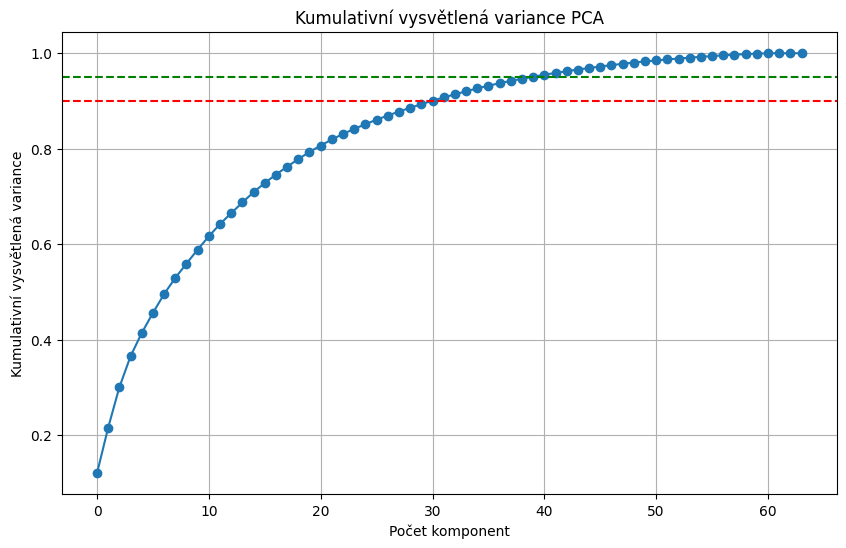

Počet komponent pro zachování 95% variance: 40


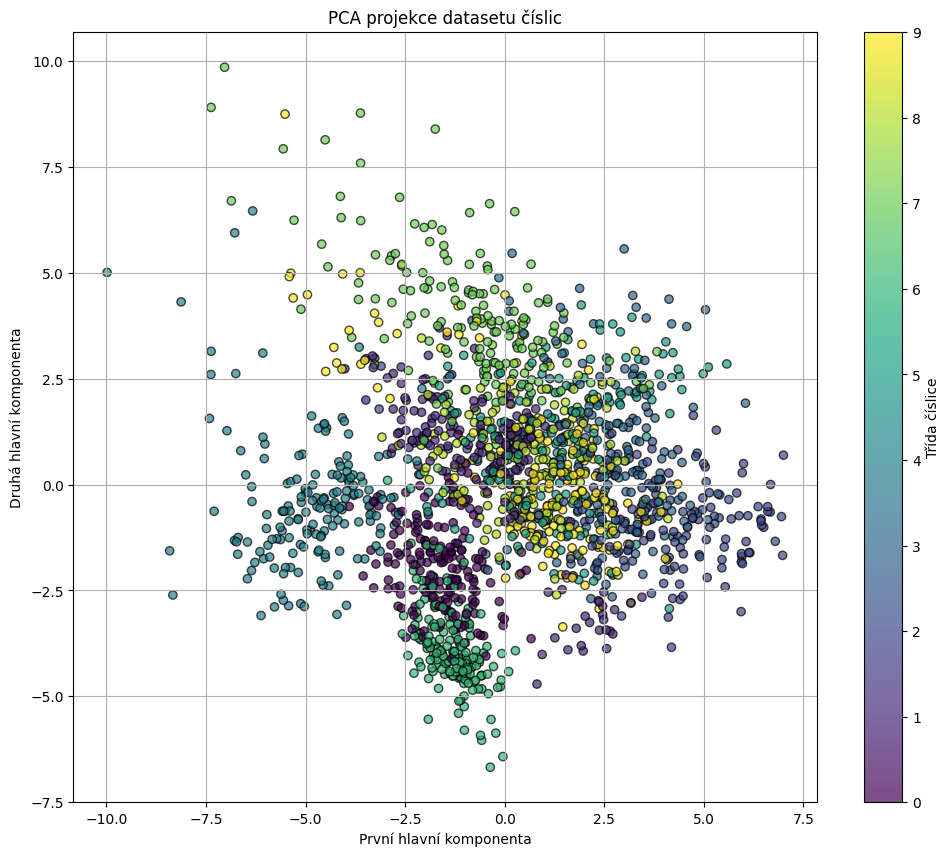

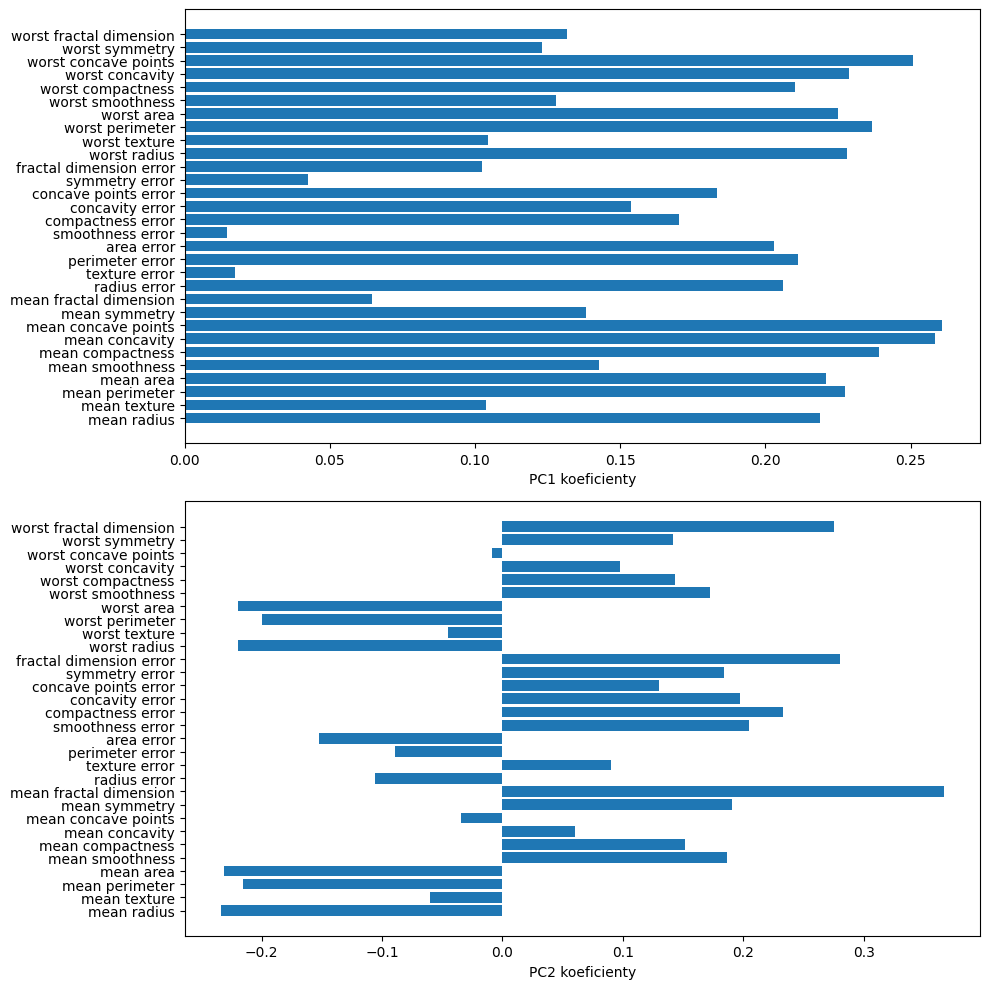

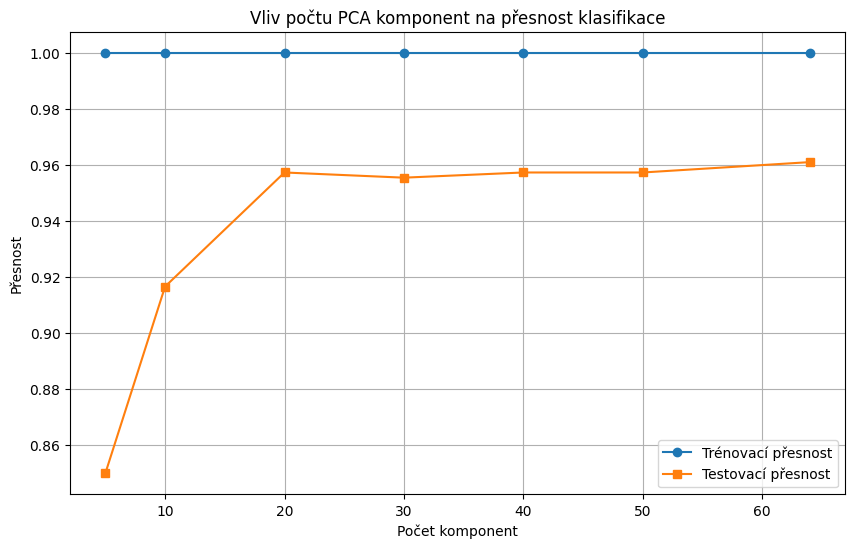

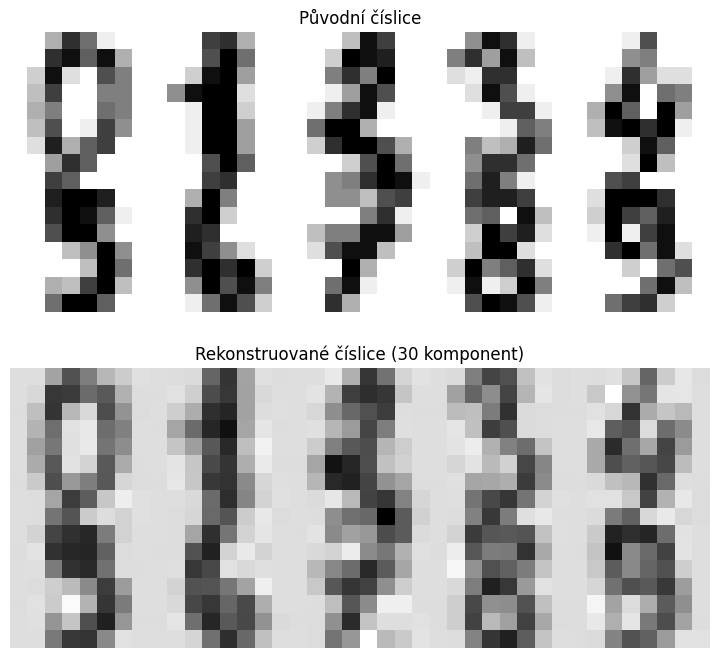

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_digits, load_breast_cancer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import seaborn as sns

# Načtení datasetu - použijeme dataset číslic
digits = load_digits()
X, y = digits.data, digits.target

# Standardizace dat
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplikace PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Vizualizace vysvětlené variance
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Počet komponent')
plt.ylabel('Kumulativní vysvětlená variance')
plt.grid(True)
plt.axhline(y=0.9, color='r', linestyle='--')
plt.axhline(y=0.95, color='g', linestyle='--')
plt.title('Kumulativní vysvětlená variance PCA')
plt.show()

# Určení počtu komponent pro zachování 95% variance
n_components = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1
print(f"Počet komponent pro zachování 95% variance: {n_components}")

# Vizualizace prvních dvou hlavních komponent
plt.figure(figsize=(12, 10))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', edgecolor='k', alpha=0.7)
plt.colorbar(label='Třída číslice')
plt.xlabel('První hlavní komponenta')
plt.ylabel('Druhá hlavní komponenta')
plt.title('PCA projekce datasetu číslic')
plt.grid(True)
plt.show()

# Vizualizace původních proměnných a jejich projekce do hlavních komponent
def plot_vector(v, components, feature_names):
    scale = 1.0 / (components.max() - components.min())
    plt.figure(figsize=(12, 6))
    for i in range(v.shape[0]):
        plt.arrow(0, 0, components[0, i]*v[i]*scale, components[1, i]*v[i]*scale,
                 head_width=0.05, head_length=0.08, fc='r', ec='r')
        plt.text(components[0, i]*v[i]*scale*1.15, components[1, i]*v[i]*scale*1.15, 
                feature_names[i], fontsize=12)
    plt.xlabel('První hlavní komponenta')
    plt.ylabel('Druhá hlavní komponenta')
    plt.grid(True)
    plt.title('Projekce původních proměnných do prvních dvou hlavních komponent')
    
# Použití na breast cancer dataset pro lepší interpretovatelnost
cancer = load_breast_cancer()
X_cancer = cancer.data
pca_cancer = PCA().fit(StandardScaler().fit_transform(X_cancer))
feature_names = cancer.feature_names

plt.figure(figsize=(10, 10))
for i, pc in enumerate(pca_cancer.components_[:2]):
    plt.subplot(2, 1, i+1)
    plt.barh(range(len(feature_names)), pc)
    plt.yticks(range(len(feature_names)), feature_names)
    plt.xlabel(f"PC{i+1} koeficienty")
plt.tight_layout()
plt.show()

# Vliv PCA na výkon klasifikátoru
# Porovnáme výkon s různým počtem komponent
n_components_list = [5, 10, 20, 30, 40, 50, 64]
train_scores = []
test_scores = []

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

for n_comp in n_components_list:
    # Vytvoření pipeline se standardizací, PCA a klasifikátorem
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=n_comp)),
        ('classifier', RandomForestClassifier(random_state=42))
    ])
    
    # Trénování
    pipeline.fit(X_train, y_train)
    
    # Vyhodnocení
    train_score = pipeline.score(X_train, y_train)
    test_score = pipeline.score(X_test, y_test)
    
    train_scores.append(train_score)
    test_scores.append(test_score)

plt.figure(figsize=(10, 6))
plt.plot(n_components_list, train_scores, 'o-', label='Trénovací přesnost')
plt.plot(n_components_list, test_scores, 's-', label='Testovací přesnost')
plt.xlabel('Počet komponent')
plt.ylabel('Přesnost')
plt.title('Vliv počtu PCA komponent na přesnost klasifikace')
plt.legend()
plt.grid(True)
plt.show()

# Ukázka rekonstrukce dat pomocí PCA
pca = PCA(n_components=30)  # Použijeme prvních 30 komponent
X_transformed = pca.fit_transform(X_scaled)
X_reconstructed = pca.inverse_transform(X_transformed)
X_reconstructed = scaler.inverse_transform(X_reconstructed)

# Vizualizace původních a rekonstruovaných číslic
def plot_digits(instances, images_per_row=5, **options):
    size = 8
    images_per_row = min(len(instances), images_per_row)
    images = [instances[i].reshape(size, size) for i in range(len(instances))]
    n_rows = (len(instances) - 1) // images_per_row + 1
    row_images = []
    n_empty = n_rows * images_per_row - len(instances)
    images.append(np.zeros((size, size)))
    for row in range(n_rows):
        row_images.append(np.concatenate([images[i] for i in range(row * images_per_row, 
                                                                 (row + 1) * images_per_row)], 
                                       axis=1))
    image = np.concatenate(row_images, axis=0)
    plt.imshow(image, cmap="binary", **options)
    plt.axis("off")

plt.figure(figsize=(15, 8))
plt.subplot(2, 1, 1)
plot_digits(X[:10])
plt.title('Původní číslice')
plt.subplot(2, 1, 2)
plot_digits(X_reconstructed[:10])
plt.title('Rekonstruované číslice (30 komponent)')
plt.show()

## 2. t-SNE (t-distributed Stochastic Neighbor Embedding)

### Popis

t-SNE je nelineární technika pro redukci dimenzionality, která je zvláště vhodná pro vizualizaci vysokodimenzionálních dat. Na rozdíl od PCA se t-SNE zaměřuje na zachování lokální struktury dat a podobnosti mezi blízkými body, což z ní činí skvělý nástroj pro vizualizaci shluků.

### Kdy a kde použít

- Pro vizualizaci vysokodimenzionálních dat v 2D nebo 3D prostoru
- Pro průzkumnou analýzu dat a identifikaci shluků
- Pokud jsou důležitější lokální struktury dat než globální
- V kombinaci s shlukovacími algoritmy
- Pro vizualizaci výstupů neuronových sítí

### Výhody a nevýhody

**Výhody:**
- Zachovává lokální strukturu dat
- Výborná pro vizualizaci shluků
- Dokáže zachytit nelineární vztahy v datech
- Často poskytuje intuitivnější vizualizace než PCA
- Dobře separuje odlišné třídy

**Nevýhody:**
- Výpočetně náročná (není vhodná pro velké datasety)
- Stochastická povaha (různé výsledky pro různá spuštění)
- Výsledky závisí na hyperparametrech (perplexita, počet iterací)
- Nezachovává globální strukturu a vzdálenosti mezi shluky
- Nelze použít pro redukci dimenzionality jako předzpracování dat (není definována transformace pro nová data)

### Ukázka kódu

In [2]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.manifold import TSNE
# from sklearn.preprocessing import StandardScaler
# from sklearn.datasets import load_digits, fetch_openml
# from sklearn.pipeline import Pipeline
# from sklearn.model_selection import train_test_split
# from time import time
# import pandas as pd
# import seaborn as sns

# # Načtení datasetu
# digits = load_digits()
# X, y = digits.data, digits.target

# # Standardizace dat
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# # Ukázka různých hodnot perplexity
# perplexities = [5, 30, 50, 100]
# plt.figure(figsize=(15, 12))

# for i, perplexity in enumerate(perplexities):
#     t0 = time()
#     tsne = TSNE(
#         n_components=2,
#         perplexity=perplexity,
#         n_iter=1000,
#         random_state=42
#     )
#     X_tsne = tsne.fit_transform(X_scaled)
#     t1 = time()
    
#     plt.subplot(2, 2, i+1)
#     plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='viridis', edgecolor='k', alpha=0.7)
#     plt.title(f'Perplexita: {perplexity}, Čas: {t1-t0:.2f}s')
#     plt.xlabel('t-SNE 1')
#     plt.ylabel('t-SNE 2')
#     plt.colorbar(label='Třída číslice')
#     plt.grid(True)

# plt.tight_layout()
# plt.show()

# # Ukázka vlivu počtu iterací
# n_iters = [250, 500, 1000, 2000]
# plt.figure(figsize=(15, 12))

# for i, n_iter in enumerate(n_iters):
#     t0 = time()
#     tsne = TSNE(
#         n_components=2,
#         perplexity=30,
#         n_iter=n_iter,
#         random_state=42
#     )
#     X_tsne = tsne.fit_transform(X_scaled)
#     t1 = time()
    
#     plt.subplot(2, 2, i+1)
#     plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='viridis', edgecolor='k', alpha=0.7)
#     plt.title(f'Počet iterací: {n_iter}, Čas: {t1-t0:.2f}s')
#     plt.xlabel('t-SNE 1')
#     plt.ylabel('t-SNE 2')
#     plt.colorbar(label='Třída číslice')
#     plt.grid(True)

# plt.tight_layout()
# plt.show()

# # Ukázka různých inicializací
# init_methods = ['random', 'pca']
# plt.figure(figsize=(15, 6))

# for i, init in enumerate(init_methods):
#     t0 = time()
#     tsne = TSNE(
#         n_components=2,
#         perplexity=30,
#         n_iter=1000,
#         init=init,
#         random_state=42
#     )
#     X_tsne = tsne.fit_transform(X_scaled)
#     t1 = time()
    
#     plt.subplot(1, 2, i+1)
#     plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='viridis', edgecolor='k', alpha=0.7)
#     plt.title(f'Inicializace: {init}, Čas: {t1-t0:.2f}s')
#     plt.xlabel('t-SNE 1')
#     plt.ylabel('t-SNE 2')
#     plt.colorbar(label='Třída číslice')
#     plt.grid(True)

# plt.tight_layout()
# plt.show()

# # Vizualizace shlukování pro různé parametry učení
# learning_rates = [10, 100, 200, 500]
# plt.figure(figsize=(15, 12))

# for i, learning_rate in enumerate(learning_rates):
#     t0 = time()
#     tsne = TSNE(
#         n_components=2,
#         perplexity=30,
#         n_iter=1000,
#         learning_rate=learning_rate,
#         random_state=42
#     )
#     X_tsne = tsne.fit_transform(X_scaled)
#     t1 = time()
    
#     plt.subplot(2, 2, i+1)
#     plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='viridis', edgecolor='k', alpha=0.7)
#     plt.title(f'Learning rate: {learning_rate}, Čas: {t1-t0:.2f}s')
#     plt.xlabel('t-SNE 1')
#     plt.ylabel('t-SNE 2')
#     plt.colorbar(label='Třída číslice')
#     plt.grid(True)

# plt.tight_layout()
# plt.show()

# # Aplikace t-SNE pro 3D vizualizaci
# tsne_3d = TSNE(n_components=3, perplexity=30, n_iter=1000, random_state=42)
# X_tsne_3d = tsne_3d.fit_transform(X_scaled)

# # 3D vizualizace
# fig = plt.figure(figsize=(12, 10))
# ax = fig.add_subplot(111, projection='3d')
# scatter = ax.scatter(X_tsne_3d[:, 0], X_tsne_3d[:, 1], X_tsne_3d[:, 2], 
#                     c=y, cmap='viridis', edgecolor='k', alpha=0.7)
# ax.set_title('3D t-SNE vizualizace datasetu číslic')
# ax.set_xlabel('t-SNE 1')
# ax.set_ylabel('t-SNE 2')
# ax.set_zlabel('t-SNE 3')
# plt.colorbar(scatter, ax=ax, label='Třída číslice')
# plt.tight_layout()
# plt.show()

# # TSNE vs PCA porovnání
# # Pro ukázku použijeme menší vzorek dat pro urychlení výpočtu
# sample_indices = np.random.permutation(len(X))[:1000]
# X_sample = X_scaled[sample_indices]
# y_sample = y[sample_indices]

# # PCA
# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X_sample)

# # t-SNE
# tsne = TSNE(n_components=2, perplexity=30, random_state=42)
# X_tsne = tsne.fit_transform(X_sample)

# plt.figure(figsize=(15, 6))
# plt.subplot(1, 2, 1)
# plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_sample, cmap='viridis', edgecolor='k', alpha=0.7)
# plt.title('PCA')
# plt.colorbar(label='Třída číslice')
# plt.grid(True)

# plt.subplot(1, 2, 2)
# plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_sample, cmap='viridis', edgecolor='k', alpha=0.7)
# plt.title('t-SNE')
# plt.colorbar(label='Třída číslice')
# plt.grid(True)

# plt.tight_layout()
# plt.show()

```
FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
```

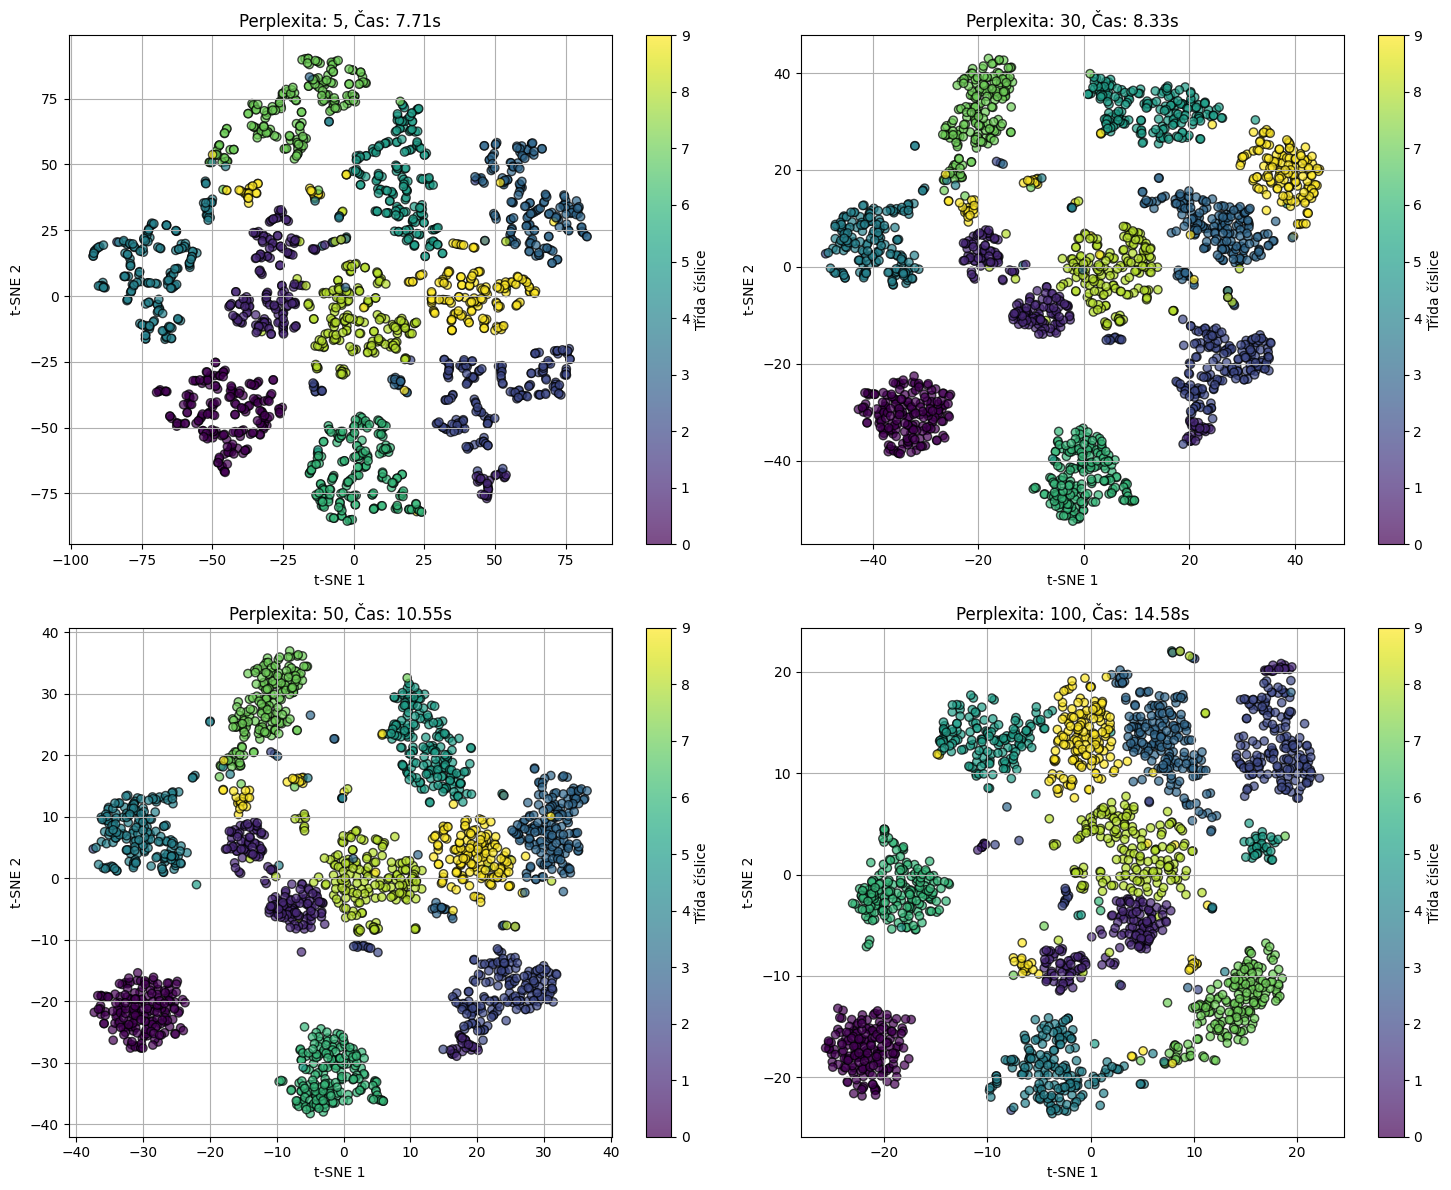

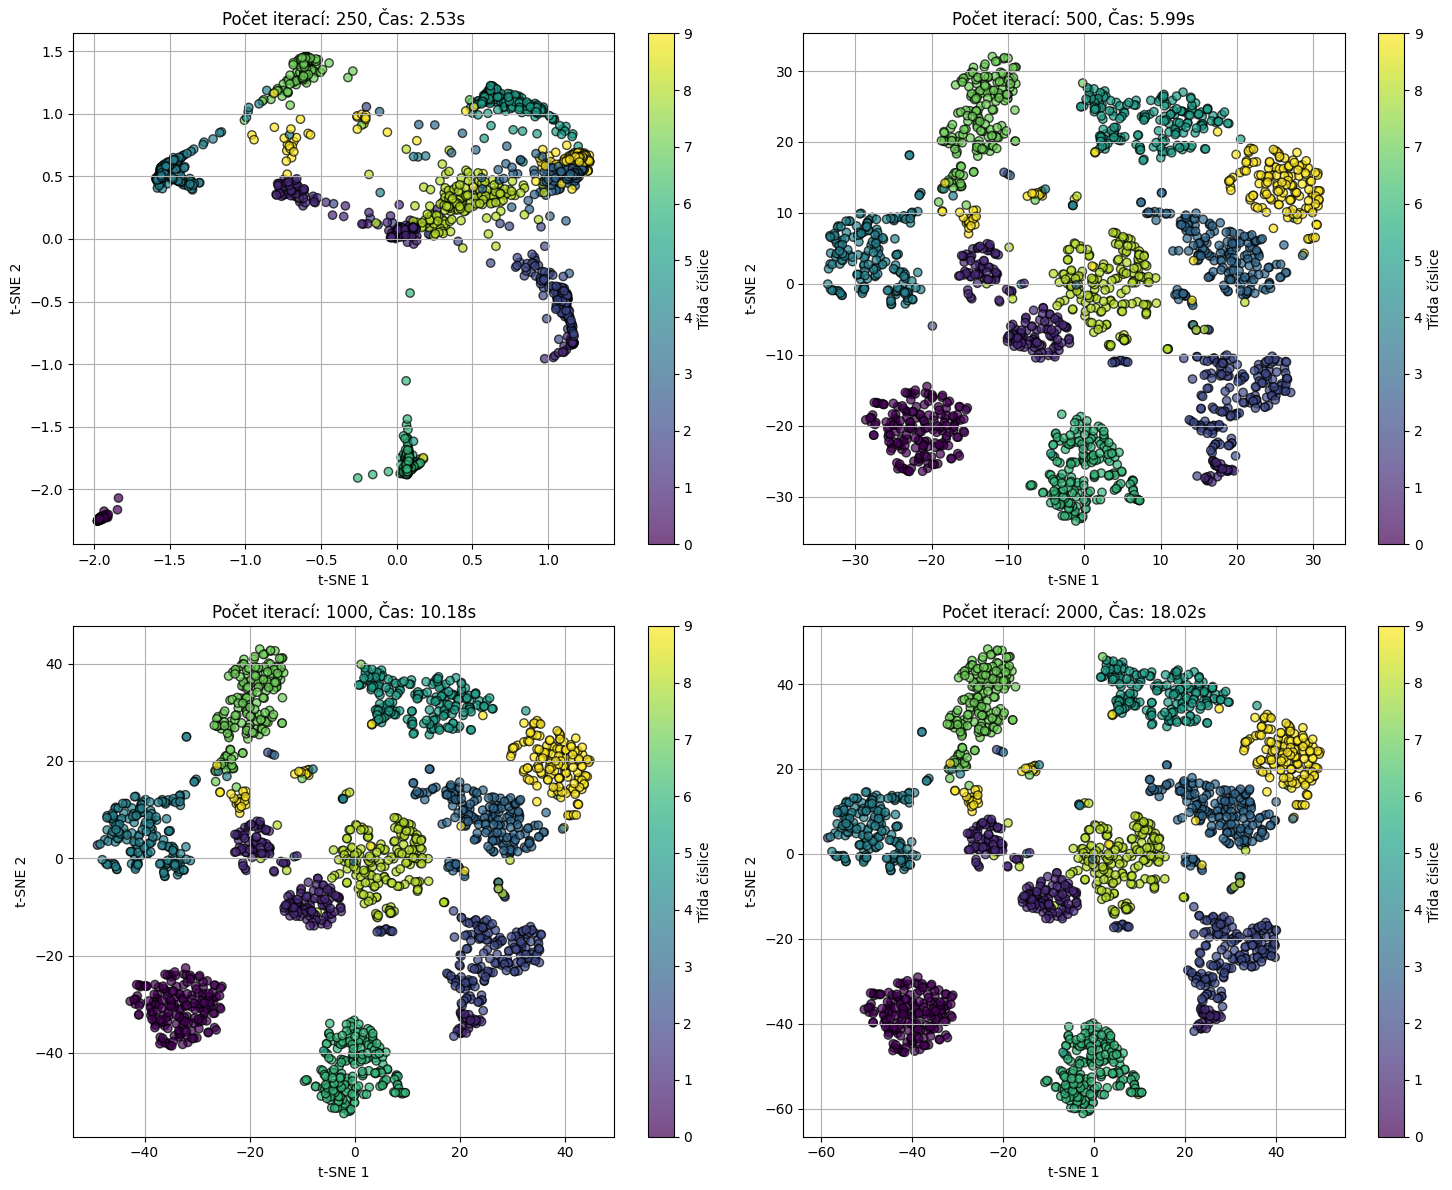

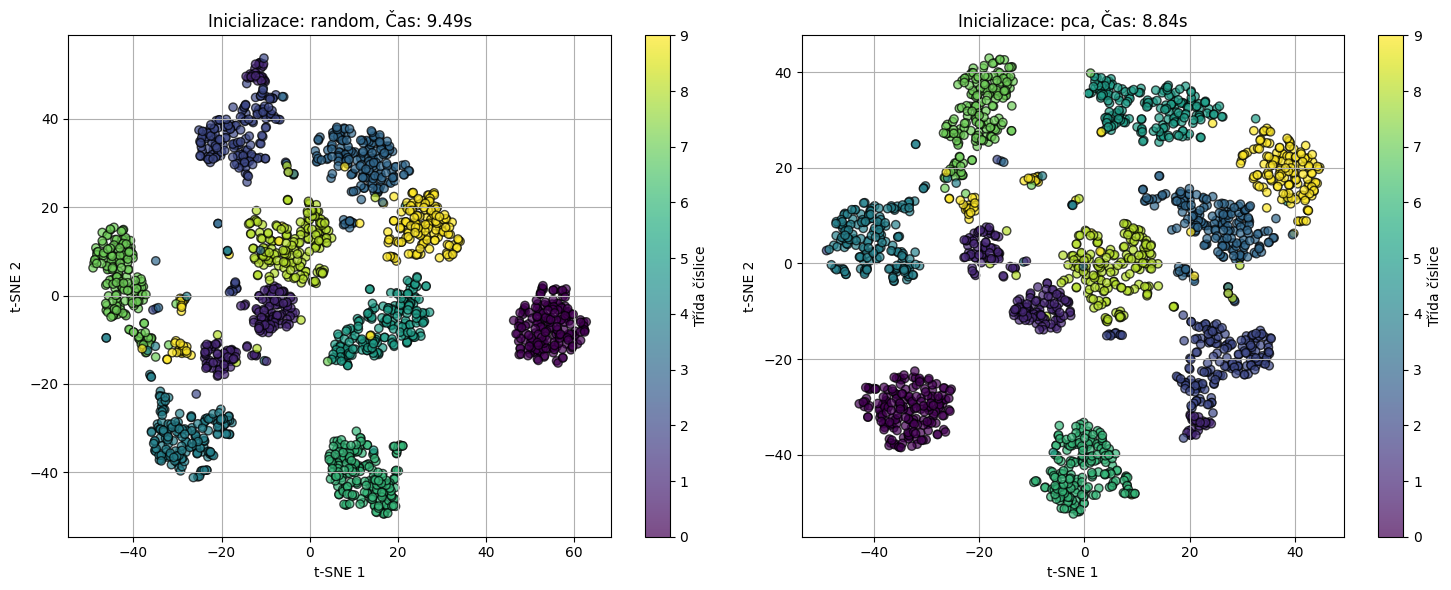

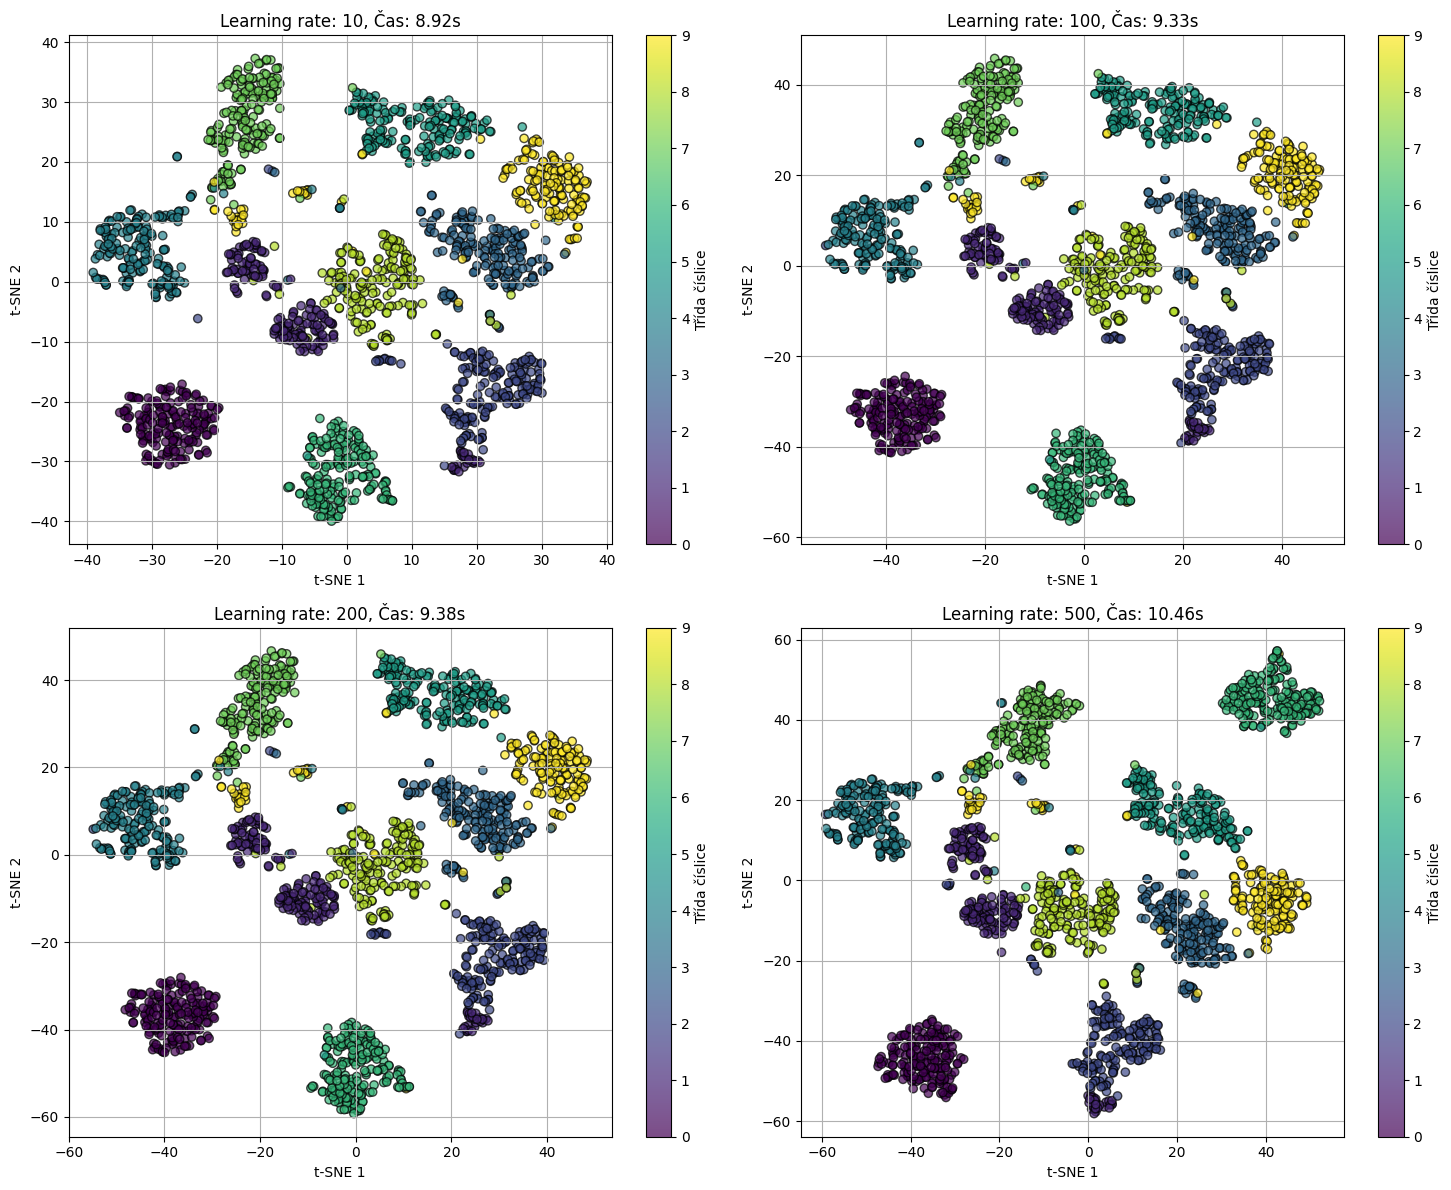

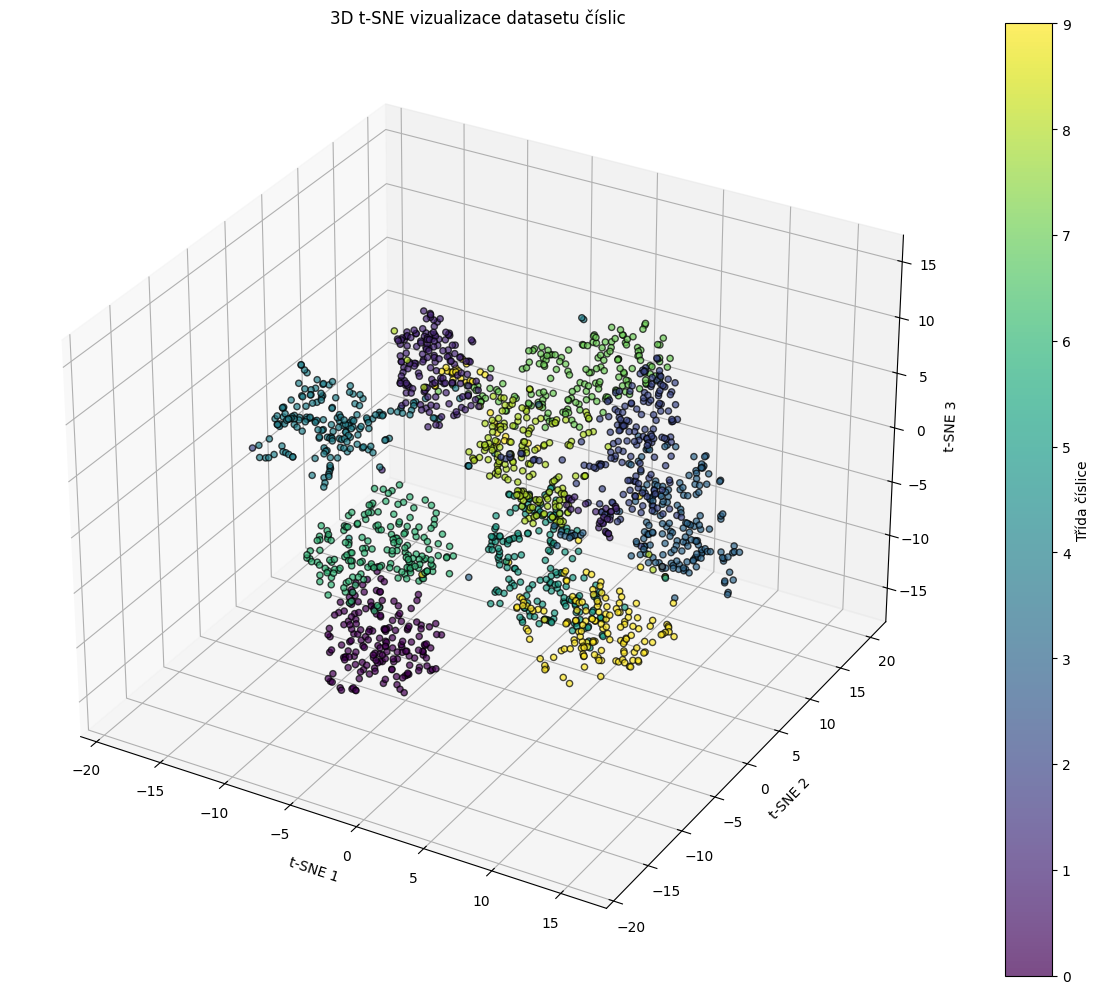

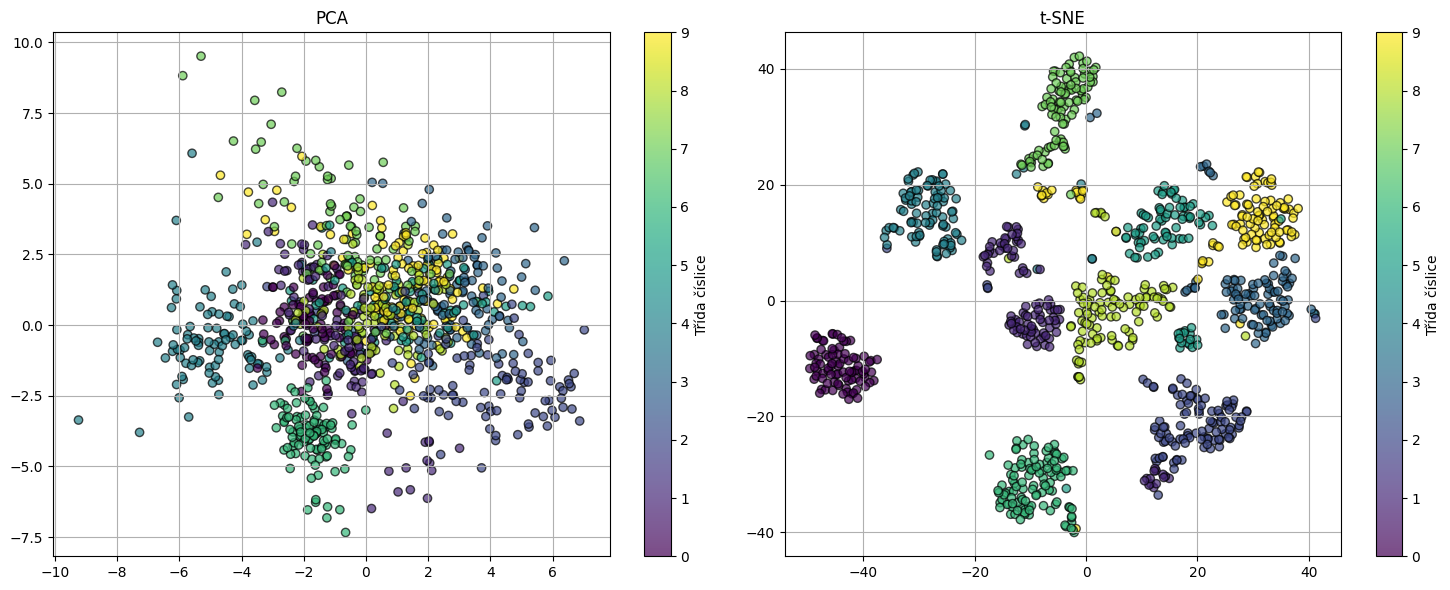

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from time import time
import pandas as pd
import seaborn as sns

# Načtení datasetu
digits = load_digits()
X, y = digits.data, digits.target

# Standardizace dat
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Ukázka různých hodnot perplexity
perplexities = [5, 30, 50, 100]
plt.figure(figsize=(15, 12))

for i, perplexity in enumerate(perplexities):
    t0 = time()
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        max_iter=1000,  # ✅ Opraveno z n_iter
        random_state=42
    )
    X_tsne = tsne.fit_transform(X_scaled)
    t1 = time()
    
    plt.subplot(2, 2, i+1)
    plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='viridis', edgecolor='k', alpha=0.7)
    plt.title(f'Perplexita: {perplexity}, Čas: {t1-t0:.2f}s')
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.colorbar(label='Třída číslice')
    plt.grid(True)

plt.tight_layout()
plt.show()

# Ukázka vlivu počtu iterací
n_iters = [250, 500, 1000, 2000]
plt.figure(figsize=(15, 12))

for i, n_iter in enumerate(n_iters):
    t0 = time()
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        max_iter=n_iter,  # ✅ Opraveno z n_iter
        random_state=42
    )
    X_tsne = tsne.fit_transform(X_scaled)
    t1 = time()
    
    plt.subplot(2, 2, i+1)
    plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='viridis', edgecolor='k', alpha=0.7)
    plt.title(f'Počet iterací: {n_iter}, Čas: {t1-t0:.2f}s')
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.colorbar(label='Třída číslice')
    plt.grid(True)

plt.tight_layout()
plt.show()

# Ukázka různých inicializací
init_methods = ['random', 'pca']
plt.figure(figsize=(15, 6))

for i, init in enumerate(init_methods):
    t0 = time()
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        max_iter=1000,  # ✅ Opraveno z n_iter
        init=init,
        random_state=42
    )
    X_tsne = tsne.fit_transform(X_scaled)
    t1 = time()
    
    plt.subplot(1, 2, i+1)
    plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='viridis', edgecolor='k', alpha=0.7)
    plt.title(f'Inicializace: {init}, Čas: {t1-t0:.2f}s')
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.colorbar(label='Třída číslice')
    plt.grid(True)

plt.tight_layout()
plt.show()

# Vizualizace shlukování pro různé parametry učení
learning_rates = [10, 100, 200, 500]
plt.figure(figsize=(15, 12))

for i, learning_rate in enumerate(learning_rates):
    t0 = time()
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        max_iter=1000,  # ✅ Opraveno z n_iter
        learning_rate=learning_rate,
        random_state=42
    )
    X_tsne = tsne.fit_transform(X_scaled)
    t1 = time()
    
    plt.subplot(2, 2, i+1)
    plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='viridis', edgecolor='k', alpha=0.7)
    plt.title(f'Learning rate: {learning_rate}, Čas: {t1-t0:.2f}s')
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.colorbar(label='Třída číslice')
    plt.grid(True)

plt.tight_layout()
plt.show()

# Aplikace t-SNE pro 3D vizualizaci
tsne_3d = TSNE(n_components=3, perplexity=30, max_iter=1000, random_state=42)  # ✅ Opraveno z n_iter
X_tsne_3d = tsne_3d.fit_transform(X_scaled)

# 3D vizualizace
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_tsne_3d[:, 0], X_tsne_3d[:, 1], X_tsne_3d[:, 2], 
                    c=y, cmap='viridis', edgecolor='k', alpha=0.7)
ax.set_title('3D t-SNE vizualizace datasetu číslic')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_zlabel('t-SNE 3')
plt.colorbar(scatter, ax=ax, label='Třída číslice')
plt.tight_layout()
plt.show()

# TSNE vs PCA porovnání
sample_indices = np.random.permutation(len(X))[:1000]
X_sample = X_scaled[sample_indices]
y_sample = y[sample_indices]

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample)

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_sample)

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_sample, cmap='viridis', edgecolor='k', alpha=0.7)
plt.title('PCA')
plt.colorbar(label='Třída číslice')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_sample, cmap='viridis', edgecolor='k', alpha=0.7)
plt.title('t-SNE')
plt.colorbar(label='Třída číslice')
plt.grid(True)

plt.tight_layout()
plt.show()

## 3. TruncatedSVD (Truncated Singular Value Decomposition)

### Popis

TruncatedSVD je metoda redukce dimenzionality založená na singulárním rozkladu matice. Na rozdíl od PCA, TruncatedSVD nevycentrovává data, což ji činí vhodnou pro řídké matice. Je široce používána v oblasti zpracování přirozeného jazyka a při práci s velkými řídkými maticemi, jako jsou matice term-document (TF-IDF).

### Kdy a kde použít

- Pro zpracování textových dat (např. s TF-IDF nebo bag-of-words reprezentací)
- Pro řídké matice, kde by PCA nebyla efektivní
- V oblasti doporučovacích systémů (latentní sémantická analýza)
- Pro redukci dimenzionality před aplikací jiných algoritmů strojového učení
- Když chceme zachovat nejdůležitější vlastnosti v řídkých datech

### Výhody a nevýhody

**Výhody:**
- Efektivní pro řídké matice (nepotřebuje jejich hustou reprezentaci)
- Výpočetně méně náročná než úplný SVD
- Používá se v latentní sémantické analýze pro textová data
- Podobný princip jako PCA, ale bez požadavku na centrování dat
- Slouží jako základ pro některé doporučovací systémy

**Nevýhody:**
- Stejně jako PCA, zachycuje pouze lineární vztahy
- Pro husté matice není o mnoho efektivnější než PCA
- Hůře interpretovatelné komponenty ve srovnání s PCA
- Může být citlivá na škálování dat
- Nezachovává všechny informace při výrazné redukci dimenzí

### Ukázka kódu

TF-IDF matice: (3749, 5000), hustota: 0.0098


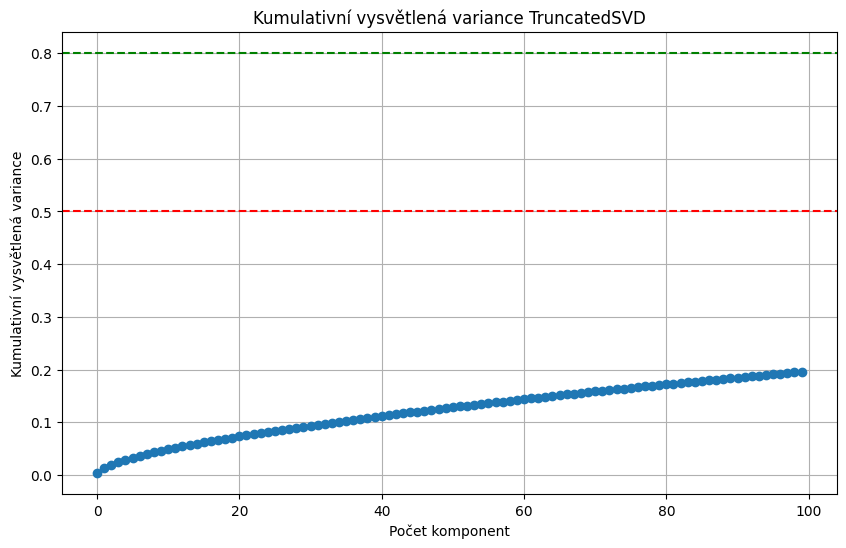

Počet komponent pro zachování 80% variance: 1
Čas výpočtu TruncatedSVD: 0.43s
Čas výpočtu PCA (včetně převodu na hustou matici): 1.17s


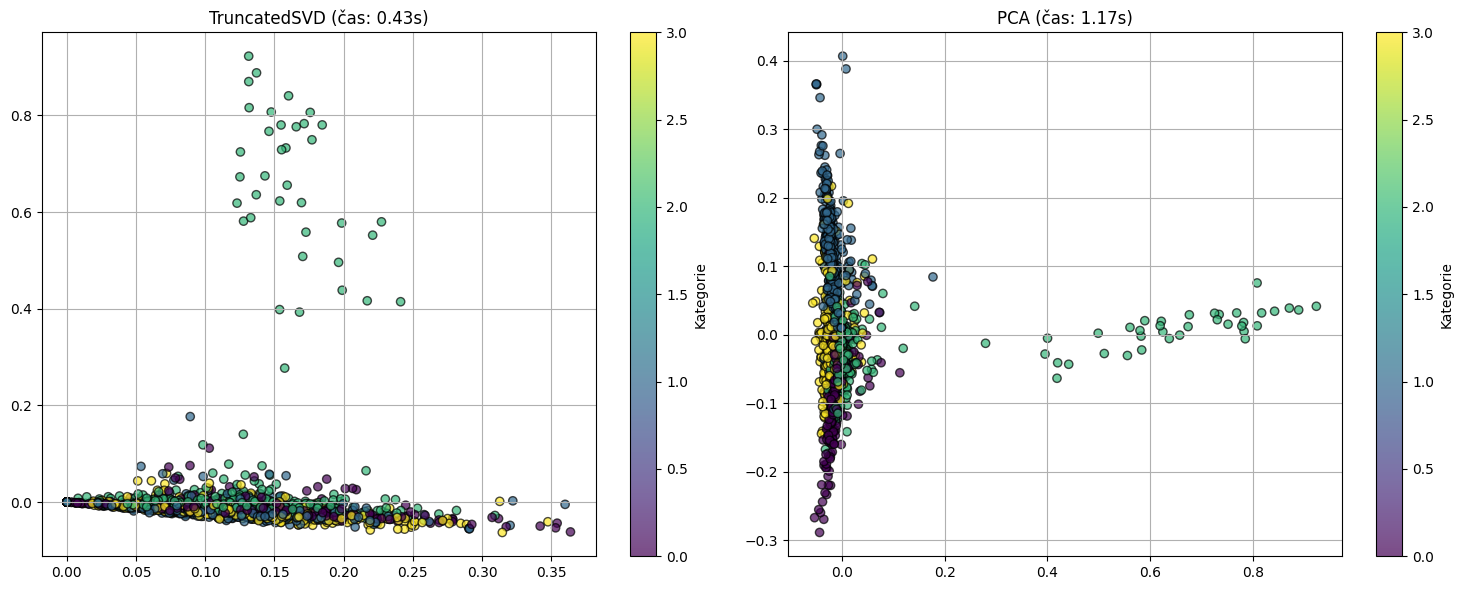


Počet komponent: 10
Trénovací přesnost: 0.9798, čas: 1.02s
Testovací přesnost: 0.8124, čas: 0.02s

Počet komponent: 50
Trénovací přesnost: 0.9798, čas: 2.20s
Testovací přesnost: 0.8267, čas: 0.02s

Počet komponent: 100
Trénovací přesnost: 0.9798, čas: 3.00s
Testovací přesnost: 0.8213, čas: 0.03s

Počet komponent: 200
Trénovací přesnost: 0.9798, čas: 4.79s
Testovací přesnost: 0.8160, čas: 0.04s

Počet komponent: 300
Trénovací přesnost: 0.9798, čas: 6.19s
Testovací přesnost: 0.8098, čas: 0.08s


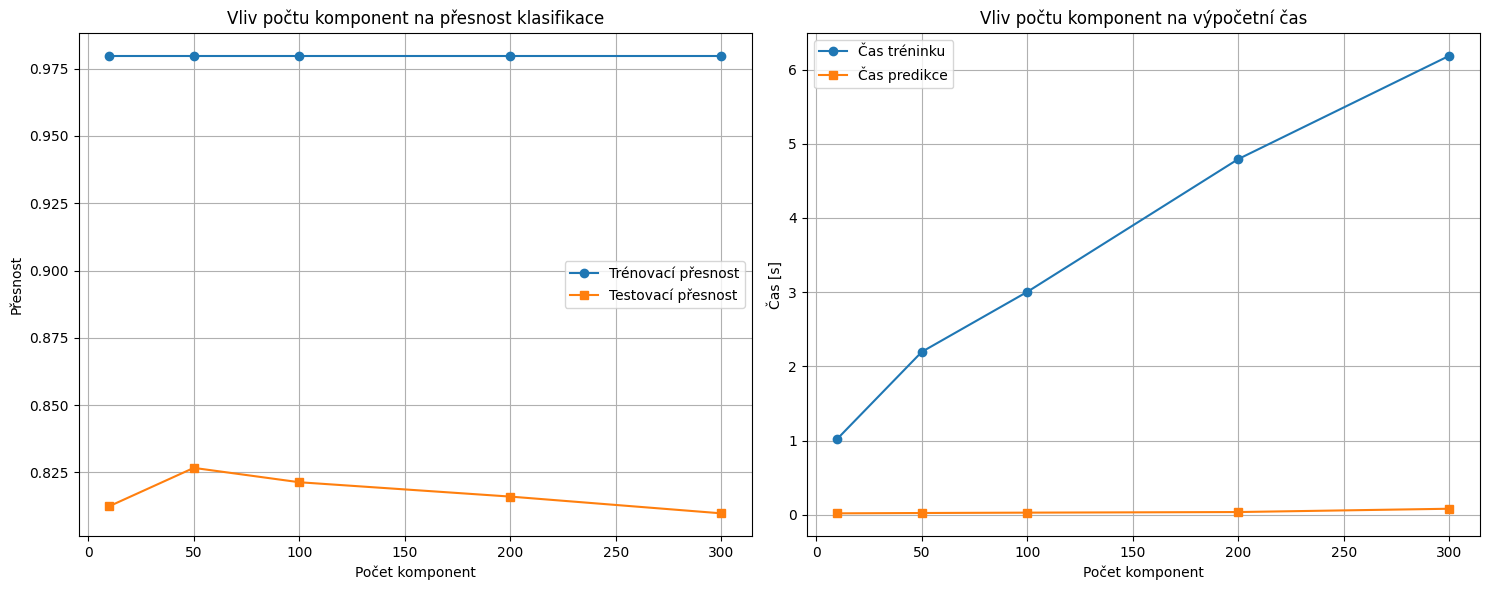


Top termy pro první komponenty:
     Komponenta 1       Komponenta 2      Komponenta 3       Komponenta 4  \
0     don (0.173)        geb (0.267)  graphics (0.224)      space (0.475)   
1   think (0.161)   shameful (0.266)    thanks (0.219)       nasa (0.219)   
2    know (0.157)        dsl (0.266)     image (0.200)    shuttle (0.151)   
3    like (0.157)      cadre (0.266)    format (0.179)     launch (0.142)   
4    just (0.151)   chastity (0.265)      file (0.173)      orbit (0.121)   
5  people (0.144)      n3jxp (0.265)     files (0.147)    station (0.119)   
6    does (0.137)  surrender (0.265)  software (0.136)       moon (0.115)   
7   space (0.132)      banks (0.264)       ftp (0.134)    mission (0.102)   
8    time (0.103)       pitt (0.263)       gif (0.132)      earth (0.095)   
9  thanks (0.099)  intellect (0.263)   program (0.124)  satellite (0.088)   

       Komponenta 5  
0       god (0.326)  
1     image (0.171)  
2  religion (0.143)  
3   atheism (0.141)  
4      fi

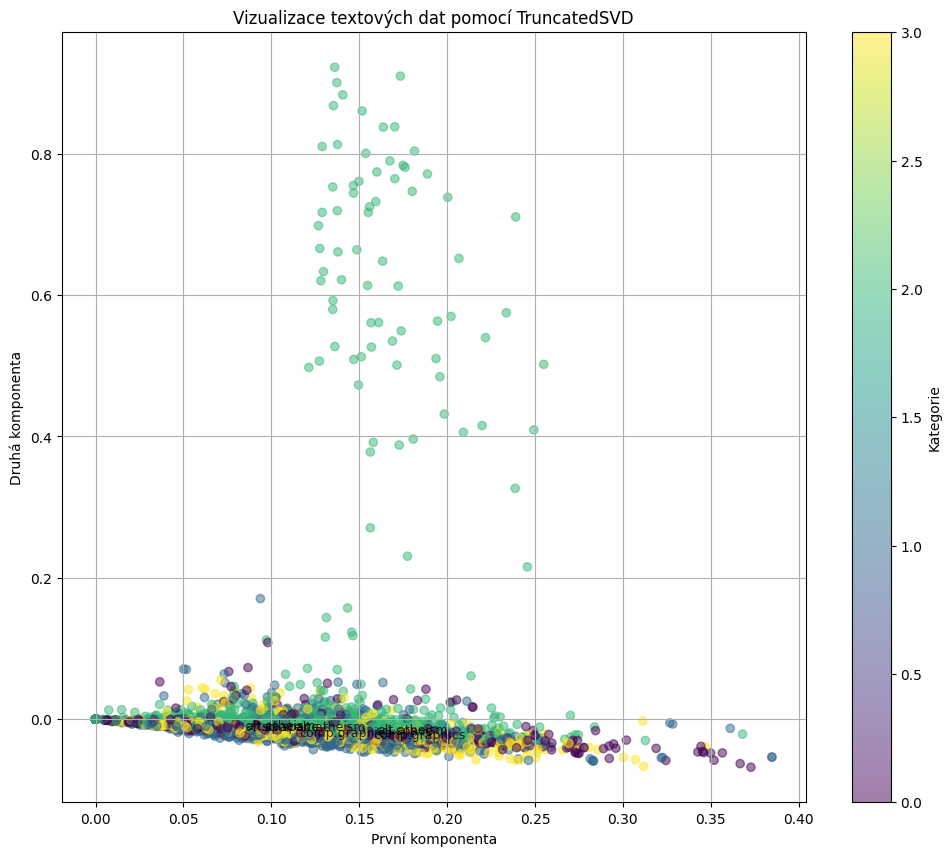

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.datasets import fetch_20newsgroups
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import seaborn as sns
from time import time
from sklearn.preprocessing import StandardScaler

# Načtení textových dat - použijeme dataset 20 Newsgroups
categories = ['alt.atheism', 'comp.graphics', 'sci.med', 'sci.space']
newsgroups = fetch_20newsgroups(subset='all', categories=categories, remove=('headers', 'footers', 'quotes'))
X_text, y_text = newsgroups.data, newsgroups.target

# Vytvoření TF-IDF matice
tfidf_vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_tfidf = tfidf_vectorizer.fit_transform(X_text)

print(f"TF-IDF matice: {X_tfidf.shape}, hustota: {X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]):.4f}")

# Aplikace TruncatedSVD
svd = TruncatedSVD(n_components=100, random_state=42)
X_svd = svd.fit_transform(X_tfidf)

# Vizualizace vysvětlené variance
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(svd.explained_variance_ratio_), marker='o')
plt.xlabel('Počet komponent')
plt.ylabel('Kumulativní vysvětlená variance')
plt.grid(True)
plt.axhline(y=0.5, color='r', linestyle='--')
plt.axhline(y=0.8, color='g', linestyle='--')
plt.title('Kumulativní vysvětlená variance TruncatedSVD')
plt.show()

# Určení počtu komponent pro zachování 80% variance
n_components_80 = np.argmax(np.cumsum(svd.explained_variance_ratio_) >= 0.8) + 1
print(f"Počet komponent pro zachování 80% variance: {n_components_80}")

# Porovnání s PCA (převod řídké matice na hustou může být paměťově náročné)
# Pro ukázku použijeme menší vzorek
sample_size = 2000
if X_tfidf.shape[0] > sample_size:
    indices = np.random.choice(X_tfidf.shape[0], sample_size, replace=False)
    X_tfidf_sample = X_tfidf[indices]
    y_text_sample = y_text[indices]
else:
    X_tfidf_sample = X_tfidf
    y_text_sample = y_text

# Měření času pro TruncatedSVD
t0 = time()
svd = TruncatedSVD(n_components=100, random_state=42)
X_svd_sample = svd.fit_transform(X_tfidf_sample)
svd_time = time() - t0
print(f"Čas výpočtu TruncatedSVD: {svd_time:.2f}s")

# Měření času pro PCA (převod na hustou matici)
t0 = time()
pca = PCA(n_components=100, random_state=42)
X_dense = X_tfidf_sample.toarray()
X_pca_sample = pca.fit_transform(X_dense)
pca_time = time() - t0
print(f"Čas výpočtu PCA (včetně převodu na hustou matici): {pca_time:.2f}s")

# Vizualizace prvních dvou komponent
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.scatter(X_svd_sample[:, 0], X_svd_sample[:, 1], c=y_text_sample, cmap='viridis', edgecolor='k', alpha=0.7)
plt.title('TruncatedSVD (čas: {:.2f}s)'.format(svd_time))
plt.colorbar(label='Kategorie')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(X_pca_sample[:, 0], X_pca_sample[:, 1], c=y_text_sample, cmap='viridis', edgecolor='k', alpha=0.7)
plt.title('PCA (čas: {:.2f}s)'.format(pca_time))
plt.colorbar(label='Kategorie')
plt.grid(True)

plt.tight_layout()
plt.show()

# Ukázka klasifikace s redukcí dimenzionality pomocí TruncatedSVD
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y_text, test_size=0.3, random_state=42)

# Porovnání výkonu klasifikátoru pro různý počet komponent
n_components_list = [10, 50, 100, 200, 300]
train_scores = []
test_scores = []
train_times = []
test_times = []

for n_comp in n_components_list:
    # Vytvoření pipeline s TruncatedSVD a klasifikátorem
    pipeline = Pipeline([
        ('svd', TruncatedSVD(n_components=n_comp, random_state=42)),
        ('classifier', RandomForestClassifier(random_state=42))
    ])
    
    # Měření času tréninku
    t0 = time()
    pipeline.fit(X_train, y_train)
    train_time = time() - t0
    train_times.append(train_time)
    
    # Měření času predikce
    t0 = time()
    y_pred = pipeline.predict(X_test)
    test_time = time() - t0
    test_times.append(test_time)
    
    # Vyhodnocení
    train_score = pipeline.score(X_train, y_train)
    test_score = pipeline.score(X_test, y_test)
    
    train_scores.append(train_score)
    test_scores.append(test_score)
    
    print(f"\nPočet komponent: {n_comp}")
    print(f"Trénovací přesnost: {train_score:.4f}, čas: {train_time:.2f}s")
    print(f"Testovací přesnost: {test_score:.4f}, čas: {test_time:.2f}s")

# Vizualizace výsledků
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.plot(n_components_list, train_scores, 'o-', label='Trénovací přesnost')
plt.plot(n_components_list, test_scores, 's-', label='Testovací přesnost')
plt.xlabel('Počet komponent')
plt.ylabel('Přesnost')
plt.title('Vliv počtu komponent na přesnost klasifikace')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(n_components_list, train_times, 'o-', label='Čas tréninku')
plt.plot(n_components_list, test_times, 's-', label='Čas predikce')
plt.xlabel('Počet komponent')
plt.ylabel('Čas [s]')
plt.title('Vliv počtu komponent na výpočetní čas')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Ukázka top termů pro každou komponentu
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())
n_top_words = 10

def print_top_words(model, feature_names, n_top_words):
    components = pd.DataFrame()
    for i, comp in enumerate(model.components_[:5]):  # Prvních 5 komponent
        top_indices = comp.argsort()[:-n_top_words - 1:-1]
        top_terms = feature_names[top_indices]
        top_weights = comp[top_indices]
        components[f"Komponenta {i+1}"] = [f"{term} ({weight:.3f})" for term, weight in zip(top_terms, top_weights)]
    return components

top_terms = print_top_words(svd, feature_names, n_top_words)
print("\nTop termy pro první komponenty:")
print(top_terms)

# Vizualizace textu v redukovaném prostoru
plt.figure(figsize=(12, 10))
plt.scatter(X_svd[:, 0], X_svd[:, 1], c=y_text, cmap='viridis', alpha=0.5)

# Přidání popisků pro některé body
for i in range(0, len(X_svd), 500):  # Každý 500. bod
    plt.annotate(
        newsgroups.target_names[y_text[i]],
        (X_svd[i, 0], X_svd[i, 1]),
        fontsize=9,
        alpha=0.8
    )

plt.title('Vizualizace textových dat pomocí TruncatedSVD')
plt.xlabel('První komponenta')
plt.ylabel('Druhá komponenta')
plt.colorbar(label='Kategorie')
plt.grid(True)
plt.show()

## 4. UMAP (Uniform Manifold Approximation and Projection)

### Popis

UMAP je moderní algoritmus pro redukci dimenzionality založený na teorii Riemannových variet a algebraické topologii. Zachovává jak lokální, tak globální strukturu dat a překonává některá omezení t-SNE, jako je zachování globálního uspořádání a značně vyšší rychlost.

### Kdy a kde použít

- Pro vizualizaci vysokodimenzionálních dat ve 2D nebo 3D prostoru
- Jako alternativa k t-SNE s lepší retencí globální struktury dat
- Pro předzpracování dat před aplikací jiných algoritmů strojového učení
- Pro data s nelineárními vztahy
- Pro velké datasety, kde je t-SNE příliš pomalý

### Výhody a nevýhody

**Výhody:**
- Zachovává jak lokální, tak globální strukturu dat
- Výrazně rychlejší než t-SNE, zvláště pro velké datasety
- Dokáže generovat transformaci pro nová data (na rozdíl od t-SNE)
- Flexibilní parametrizace pro různé druhy dat
- Často poskytuje lepší vizuální separaci shluků

**Nevýhody:**
- Vyžaduje instalaci externího balíčku (není součástí základní instalace scikit-learn)
- Citlivý na výběr hyperparametrů
- Méně teoreticky podložený než PCA nebo SVD
- Stále relativně nový algoritmus s vyvíjející se implementací
- Může být náročnější na interpretaci výsledků

### Ukázka kódu

In [5]:
# !pip install umap-learn

In [6]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.datasets import load_digits, fetch_openml
# from sklearn.preprocessing import StandardScaler
# from sklearn.model_selection import train_test_split
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.metrics import accuracy_score
# from time import time
# import pandas as pd
# import seaborn as sns
# import warnings

# # Potřebujeme nainstalovat UMAP: pip install umap-learn
# try:
#     import umap
# except ImportError:
#     print("Pro tuto ukázku je třeba nainstalovat knihovnu umap-learn: pip install umap-learn")
#     # Pro ilustraci kódu pokračujeme i bez ní
#     class DummyUMAP:
#         def __init__(self, **kwargs):
#             pass
#         def fit_transform(self, X):
#             # Vrátí náhodnou projekci pro ukázkové účely
#             return np.random.randn(X.shape[0], 2)
#     umap = type('module', (), {'UMAP': DummyUMAP})
#     warnings.warn("Používám simulovanou implementaci UMAP pro ilustraci kódu!")

# # Načtení datasetu
# digits = load_digits()
# X, y = digits.data, digits.target

# # Standardizace dat
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# # Aplikace UMAP s různými parametry
# n_neighbors_list = [5, 15, 30, 50]
# min_dist_list = [0.0, 0.1, 0.5, 1.0]

# fig, axes = plt.subplots(len(n_neighbors_list), len(min_dist_list), figsize=(20, 20))

# for i, n_neighbors in enumerate(n_neighbors_list):
#     for j, min_dist in enumerate(min_dist_list):
#         t0 = time()
#         embedding = umap.UMAP(
#             n_neighbors=n_neighbors,
#             min_dist=min_dist,
#             n_components=2,
#             random_state=42
#         ).fit_transform(X_scaled)
#         t1 = time()
        
#         ax = axes[i, j]
#         scatter = ax.scatter(embedding[:, 0], embedding[:, 1], c=y, cmap='viridis', s=5)
#         ax.set_title(f'n_neighbors={n_neighbors}, min_dist={min_dist}\nČas: {t1-t0:.2f}s')
#         ax.set_xticks([])
#         ax.set_yticks([])

# plt.tight_layout()
# plt.show()

# # Porovnání UMAP, t-SNE a PCA na stejných datech
# from sklearn.decomposition import PCA
# from sklearn.manifold import TSNE

# # Pro ukázku použijeme menší vzorek dat pro urychlení výpočtu t-SNE
# sample_size = 1000
# indices = np.random.choice(len(X), sample_size, replace=False)
# X_sample = X_scaled[indices]
# y_sample = y[indices]

# # PCA
# t0 = time()
# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X_sample)
# t_pca = time() - t0

# # t-SNE
# t0 = time()
# tsne = TSNE(n_components=2, perplexity=30, random_state=42)
# X_tsne = tsne.fit_transform(X_sample)
# t_tsne = time() - t0

# # UMAP
# t0 = time()
# reducer = umap.UMAP(random_state=42)
# X_umap = reducer.fit_transform(X_sample)
# t_umap = time() - t0

# # Vizualizace výsledků
# plt.figure(figsize=(18, 6))
# plt.subplot(1, 3, 1)
# plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_sample, cmap='viridis', s=30, edgecolor='k', alpha=0.7)
# plt.title(f'PCA (čas: {t_pca:.2f}s)')
# plt.colorbar(label='Třída číslice')
# plt.grid(True)

# plt.subplot(1, 3, 2)
# plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_sample, cmap='viridis', s=30, edgecolor='k', alpha=0.7)
# plt.title(f't-SNE (čas: {t_tsne:.2f}s)')
# plt.colorbar(label='Třída číslice')
# plt.grid(True)

# plt.subplot(1, 3, 3)
# plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y_sample, cmap='viridis', s=30, edgecolor='k', alpha=0.7)
# plt.title(f'UMAP (čas: {t_umap:.2f}s)')
# plt.colorbar(label='Třída číslice')
# plt.grid(True)

# plt.tight_layout()
# plt.show()

# # Ukázka transformace nových dat pomocí UMAP
# X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# # Trénování UMAP na trénovacích datech
# umap_model = umap.UMAP(random_state=42)
# X_train_umap = umap_model.fit_transform(X_train)

# # Transformace testovacích dat - toto u t-SNE není možné
# X_test_umap = umap_model.transform(X_test)

# # Vizualizace
# plt.figure(figsize=(15, 6))
# plt.subplot(1, 2, 1)
# plt.scatter(X_train_umap[:, 0], X_train_umap[:, 1], c=y_train, cmap='viridis', s=30, edgecolor='k', alpha=0.7)
# plt.title('UMAP projekce trénovacích dat')
# plt.colorbar(label='Třída číslice')
# plt.grid(True)

# plt.subplot(1, 2, 2)
# plt.scatter(X_test_umap[:, 0], X_test_umap[:, 1], c=y_test, cmap='viridis', s=30, edgecolor='k', alpha=0.7)
# plt.title('UMAP projekce testovacích dat')
# plt.colorbar(label='Třída číslice')
# plt.grid(True)

# plt.tight_layout()
# plt.show()

# # Ukázka použití UMAP pro zlepšení výkonu klasifikátoru
# # Porovnáme výkon KNN na původních datech a na datech promítnutých pomocí UMAP

# # KNN na původních datech
# knn_orig = KNeighborsClassifier(n_neighbors=5)
# t0 = time()
# knn_orig.fit(X_train, y_train)
# t_train_orig = time() - t0

# t0 = time()
# y_pred_orig = knn_orig.predict(X_test)
# t_pred_orig = time() - t0

# acc_orig = accuracy_score(y_test, y_pred_orig)

# # KNN na UMAP projekci
# n_components_list = [2, 5, 10, 20]
# results = []

# for n_comp in n_components_list:
#     umap_model = umap.UMAP(n_components=n_comp, random_state=42)
    
#     t0 = time()
#     X_train_umap = umap_model.fit_transform(X_train)
#     X_test_umap = umap_model.transform(X_test)
#     t_umap = time() - t0
    
#     knn_umap = KNeighborsClassifier(n_neighbors=5)
    
#     t0 = time()
#     knn_umap.fit(X_train_umap, y_train)
#     t_train_umap = time() - t0
    
#     t0 = time()
#     y_pred_umap = knn_umap.predict(X_test_umap)
#     t_pred_umap = time() - t0
    
#     acc_umap = accuracy_score(y_test, y_pred_umap)
    
#     results.append({
#         'n_components': n_comp,
#         'accuracy': acc_umap,
#         'umap_time': t_umap,
#         'train_time': t_train_umap,
#         'pred_time': t_pred_umap,
#         'total_time': t_umap + t_train_umap + t_pred_umap
#     })

# # Vytvoření přehledové tabulky
# results_df = pd.DataFrame(results)
# print("\nVýkon KNN klasifikátoru na původních datech:")
# print(f"Přesnost: {acc_orig:.4f}")
# print(f"Čas tréninku: {t_train_orig:.4f}s")
# print(f"Čas predikce: {t_pred_orig:.4f}s")
# print("\nVýkon KNN klasifikátoru na UMAP projekci:")
# print(results_df)

# # Vizualizace výsledků
# plt.figure(figsize=(15, 6))

# plt.subplot(1, 2, 1)
# plt.plot(results_df['n_components'], results_df['accuracy'], 'o-')
# plt.axhline(y=acc_orig, color='r', linestyle='--', label=f'Původní data ({acc_orig:.4f})')
# plt.xlabel('Počet komponent UMAP')
# plt.ylabel('Přesnost')
# plt.title('Vliv počtu komponent na přesnost klasifikace')
# plt.legend()
# plt.grid(True)

# plt.subplot(1, 2, 2)
# plt.plot(results_df['n_components'], results_df['total_time'], 'o-', label='Celkový čas UMAP')
# plt.plot(results_df['n_components'], results_df['train_time'], 's-', label='Čas tréninku')
# plt.plot(results_df['n_components'], results_df['pred_time'], '^-', label='Čas predikce')
# plt.axhline(y=t_train_orig+t_pred_orig, color='r', linestyle='--', label=f'Původní data ({t_train_orig+t_pred_orig:.4f}s)')
# plt.xlabel('Počet komponent UMAP')
# plt.ylabel('Čas [s]')
# plt.title('Vliv počtu komponent na výpočetní čas')
# plt.legend()
# plt.grid(True)

# plt.tight_layout()
# file:///C:/Users/pavel/projects/ai-ml/.venv/Lib/site-packages/sklearn/utils/deprecation.py#line=150plt.show()

```
UserWarning: Používám simulovanou implementaci UMAP pro ilustraci kódu!
  warnings.warn("Používám simulovanou implementaci UMAP pro ilustraci kódu!")

AttributeError: 'DummyUMAP' object has no attribute 'transform'
```

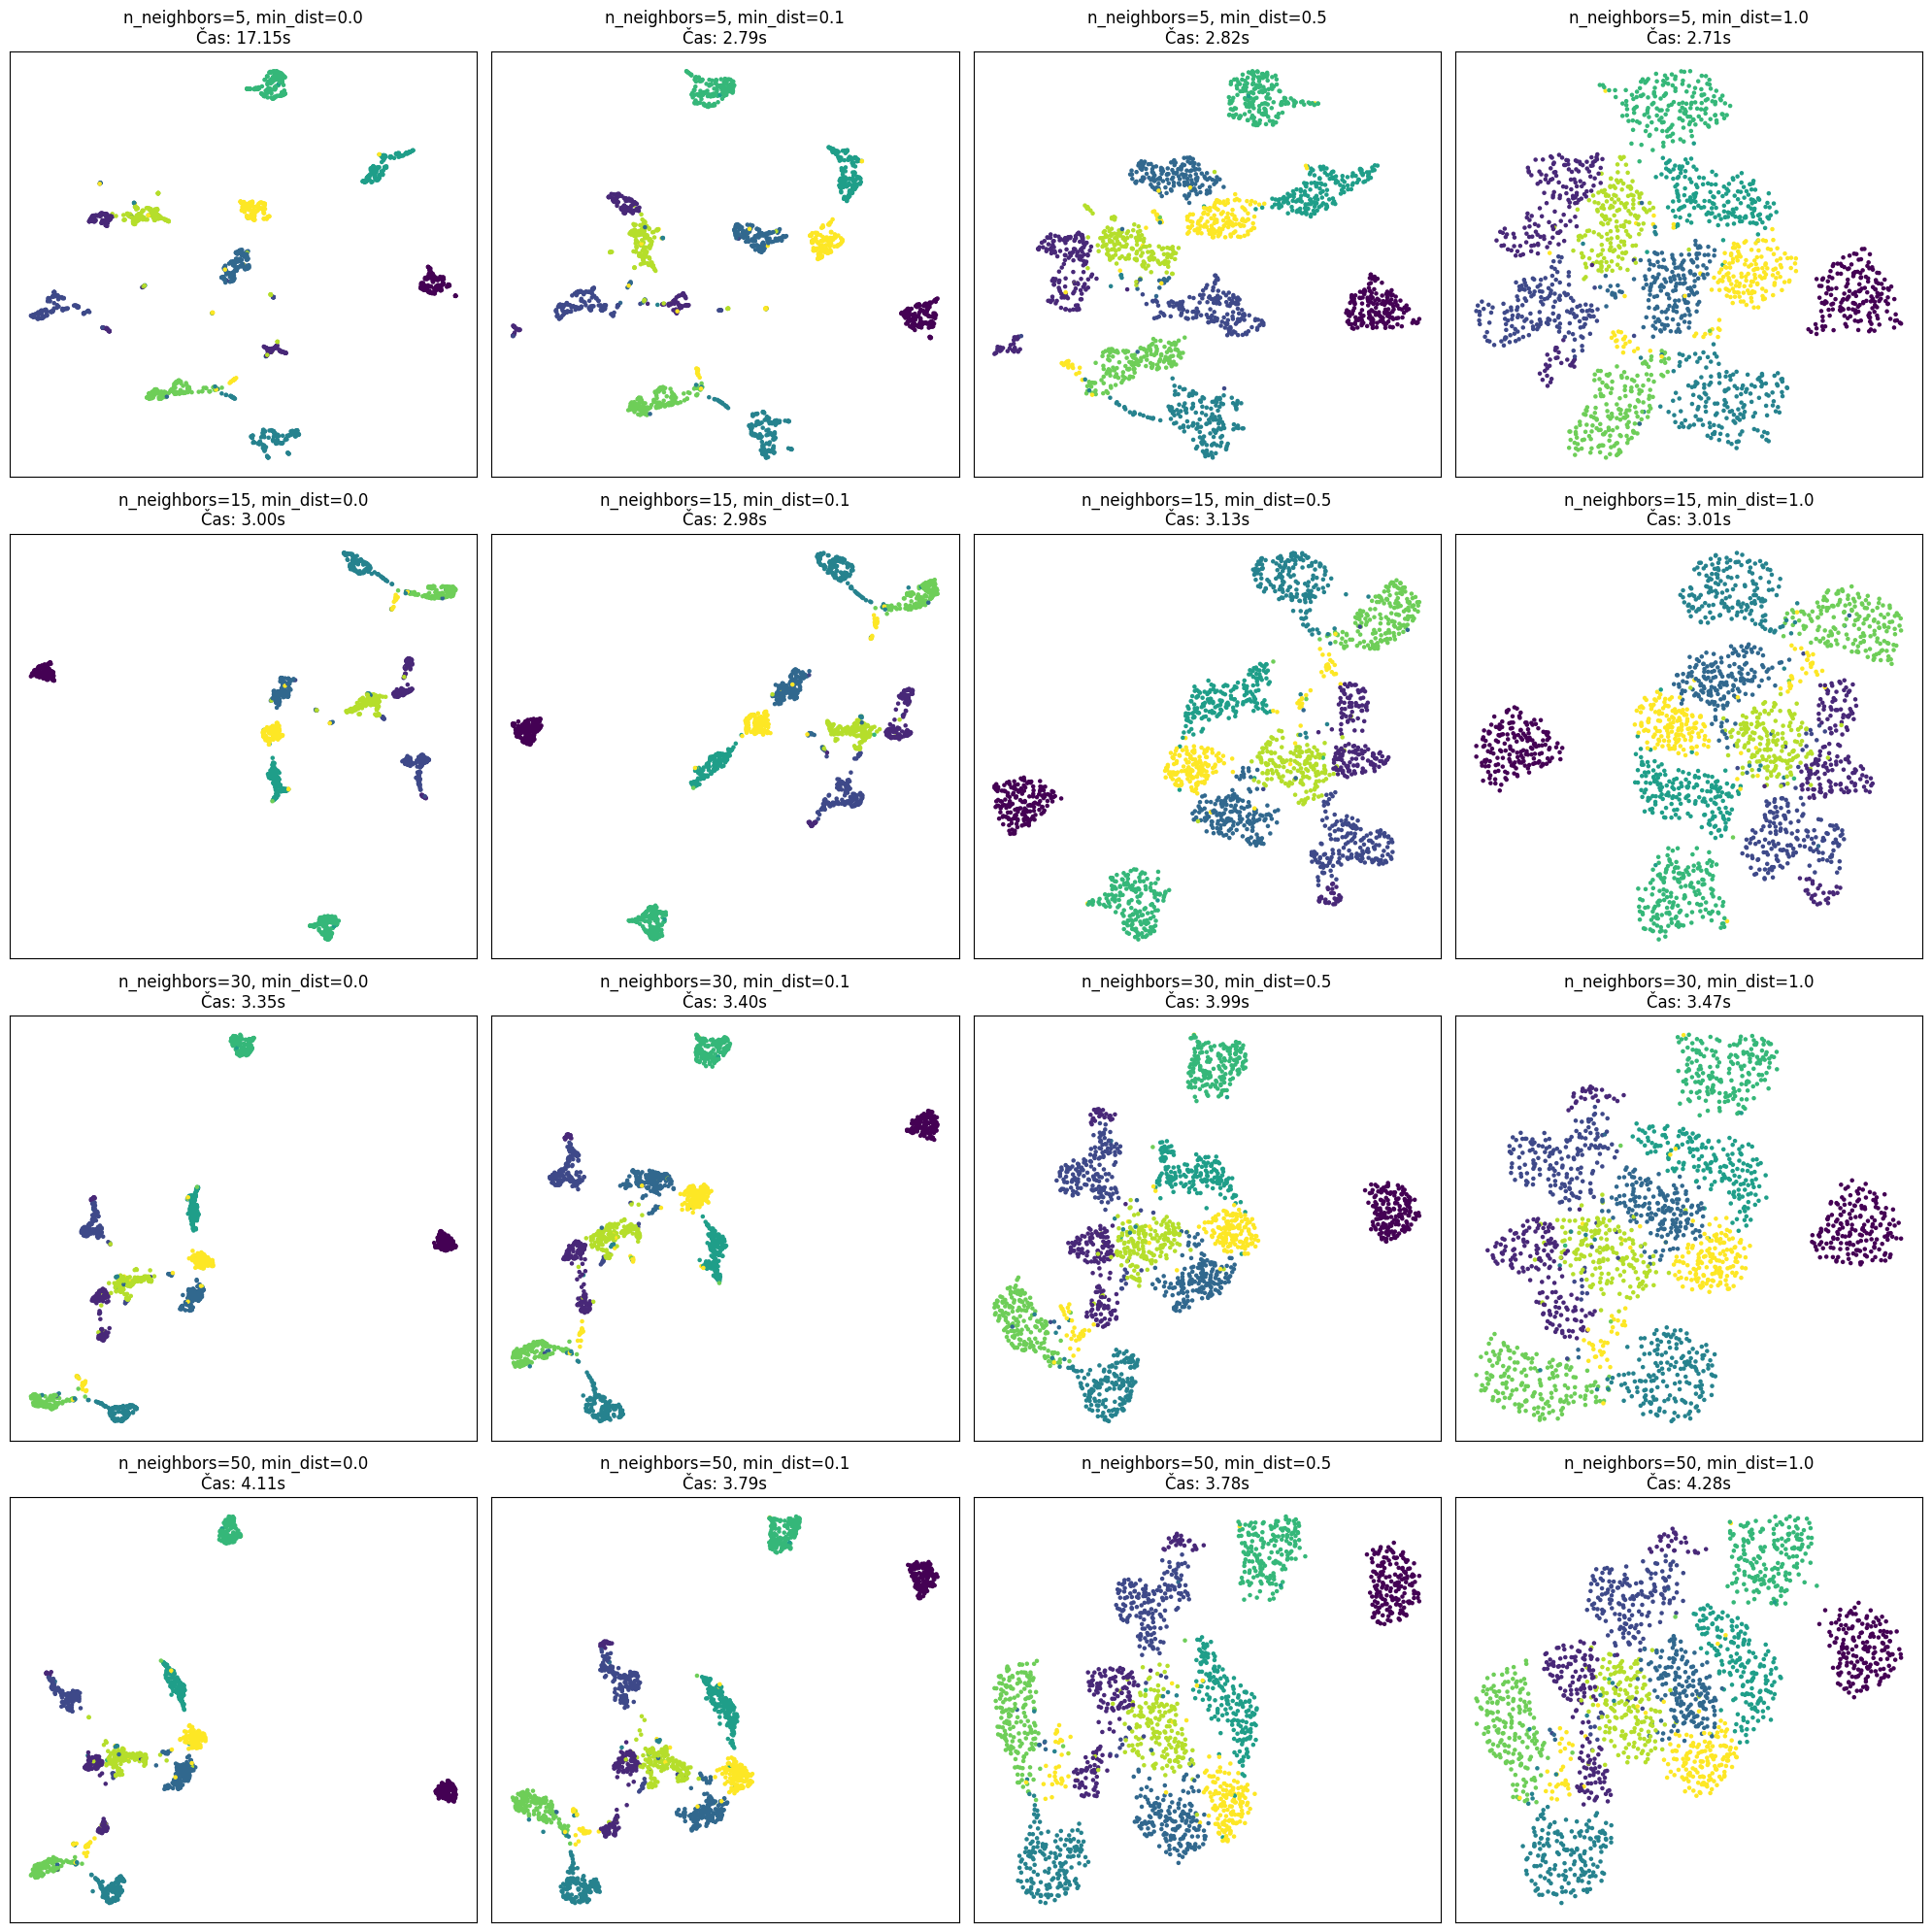

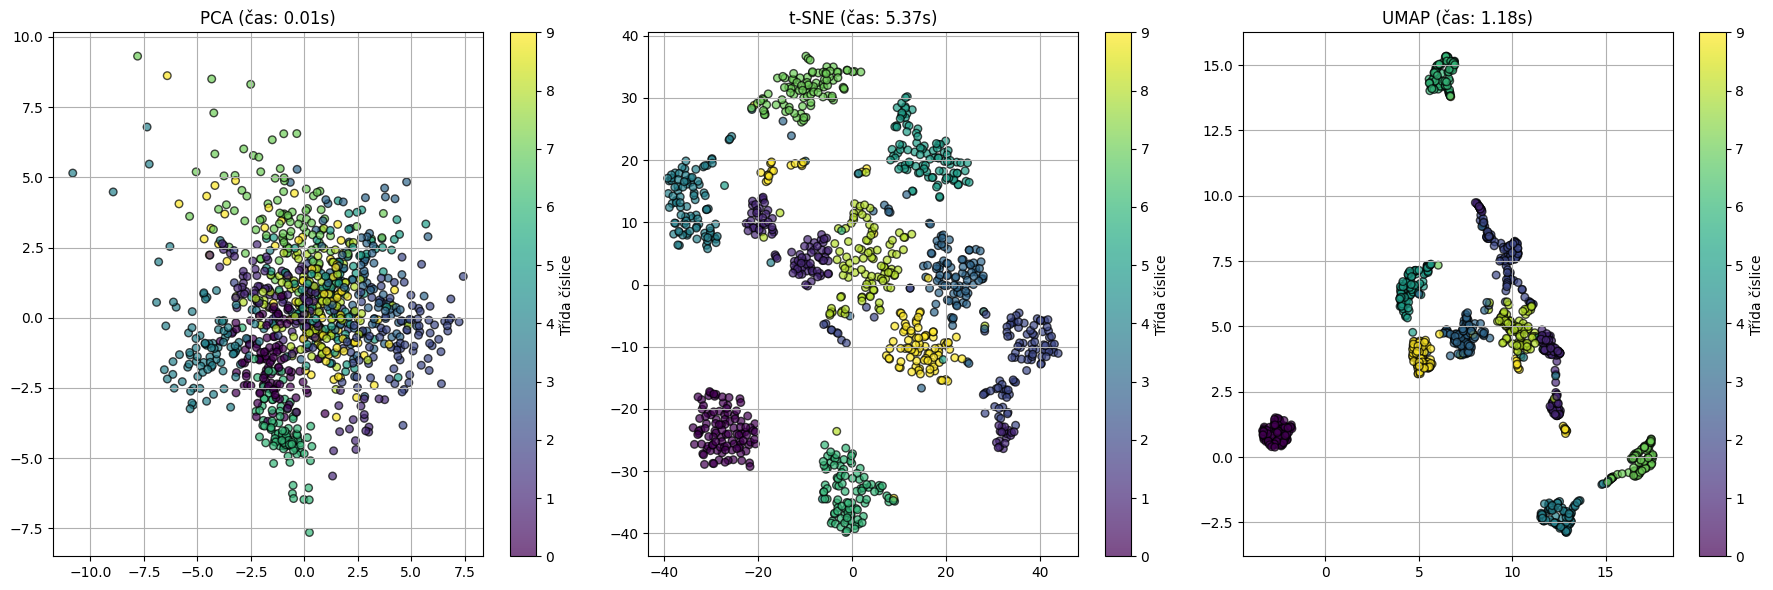

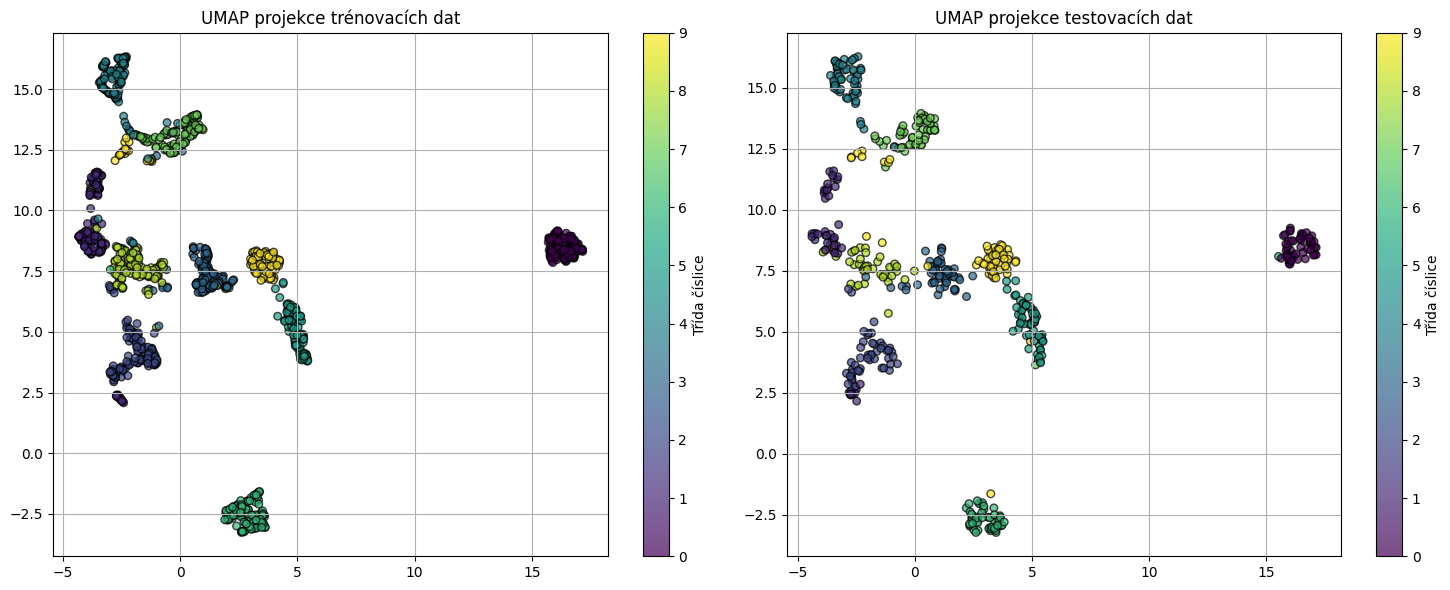


Výkon KNN klasifikátoru na původních datech:
Přesnost: 0.9778
Čas tréninku: 0.0010s
Čas predikce: 0.0891s

Výkon KNN klasifikátoru na UMAP projekci:
   n_components  accuracy  umap_time  train_time  pred_time  total_time
0             2  0.955556   2.892501    0.001999   0.033001    2.927502
1             5  0.953704   2.850332    0.001505   0.034166    2.886004
2            10  0.961111   3.099788    0.003000   0.039000    3.141788
3            20  0.959259   3.092349    0.001001   0.005998    3.099348


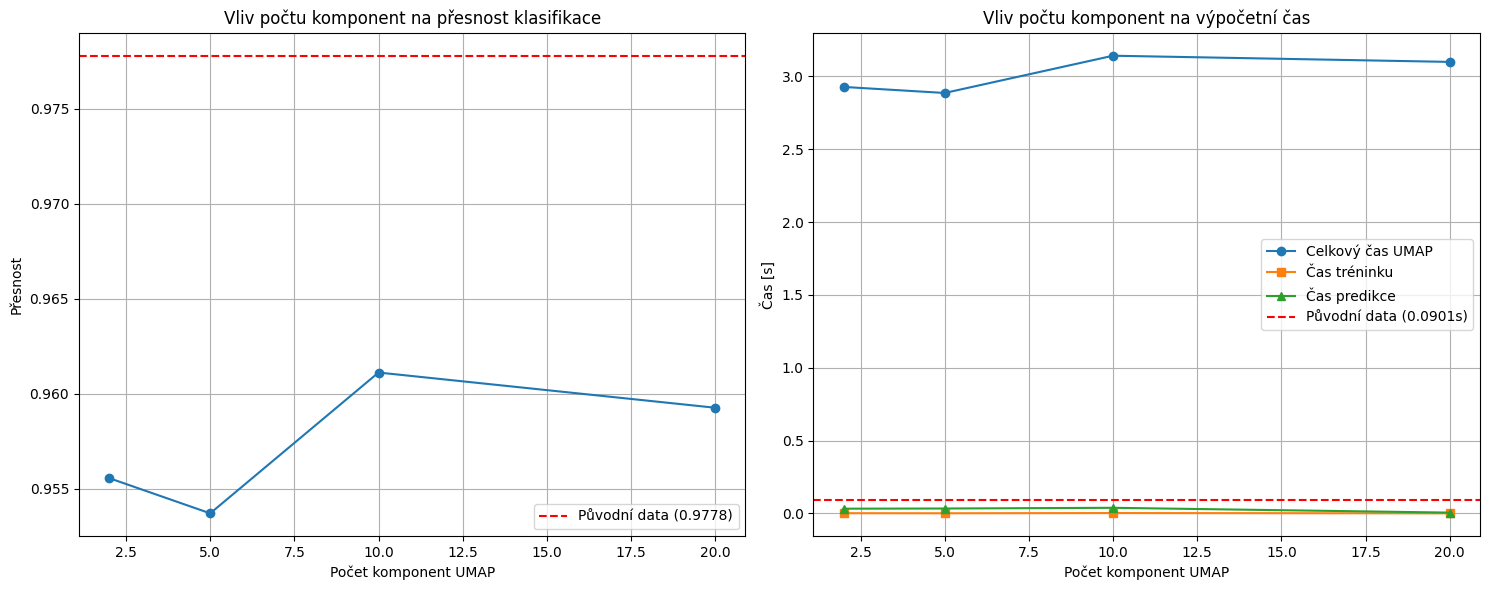

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits, fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from time import time
import pandas as pd
import seaborn as sns
import warnings

# Suppress specific FutureWarning about force_all_finite
warnings.filterwarnings("ignore", message=".*force_all_finite.*ensure_all_finite.*")

# Potřebujeme nainstalovat UMAP: pip install umap-learn
try:
    import umap
except ImportError:
    print("Pro tuto ukázku je třeba nainstalovat knihovnu umap-learn: pip install umap-learn")
    # Pro ilustraci kódu pokračujeme i bez ní
    class DummyUMAP:
        def __init__(self, **kwargs):
            pass
        def fit_transform(self, X):
            # Vrátí náhodnou projekci pro ukázkové účely
            return np.random.randn(X.shape[0], 2)
    umap = type('module', (), {'UMAP': DummyUMAP})
    warnings.warn("Používám simulovanou implementaci UMAP pro ilustraci kódu!")

# Načtení datasetu
digits = load_digits()
X, y = digits.data, digits.target

# Standardizace dat
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplikace UMAP s různými parametry
n_neighbors_list = [5, 15, 30, 50]
min_dist_list = [0.0, 0.1, 0.5, 1.0]

fig, axes = plt.subplots(len(n_neighbors_list), len(min_dist_list), figsize=(20, 20))

for i, n_neighbors in enumerate(n_neighbors_list):
    for j, min_dist in enumerate(min_dist_list):
        t0 = time()
        # Odstraněno n_jobs (bude použita výchozí hodnota), což vyřeší konflikt s random_state
        embedding = umap.UMAP(
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            n_components=2,
            random_state=None  # Změna na None místo 42, aby se zabránilo konfliktu s n_jobs
        ).fit_transform(X_scaled)
        t1 = time()
        
        ax = axes[i, j]
        scatter = ax.scatter(embedding[:, 0], embedding[:, 1], c=y, cmap='viridis', s=5)
        ax.set_title(f'n_neighbors={n_neighbors}, min_dist={min_dist}\nČas: {t1-t0:.2f}s')
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()

# Porovnání UMAP, t-SNE a PCA na stejných datech
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Pro ukázku použijeme menší vzorek dat pro urychlení výpočtu t-SNE
sample_size = 1000
indices = np.random.choice(len(X), sample_size, replace=False)
X_sample = X_scaled[indices]
y_sample = y[indices]

# PCA
t0 = time()
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample)
t_pca = time() - t0

# t-SNE
t0 = time()
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_sample)
t_tsne = time() - t0

# UMAP
t0 = time()
reducer = umap.UMAP(random_state=None)  # Odstraněno random_state=42
X_umap = reducer.fit_transform(X_sample)
t_umap = time() - t0

# Vizualizace výsledků
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_sample, cmap='viridis', s=30, edgecolor='k', alpha=0.7)
plt.title(f'PCA (čas: {t_pca:.2f}s)')
plt.colorbar(label='Třída číslice')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_sample, cmap='viridis', s=30, edgecolor='k', alpha=0.7)
plt.title(f't-SNE (čas: {t_tsne:.2f}s)')
plt.colorbar(label='Třída číslice')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y_sample, cmap='viridis', s=30, edgecolor='k', alpha=0.7)
plt.title(f'UMAP (čas: {t_umap:.2f}s)')
plt.colorbar(label='Třída číslice')
plt.grid(True)

plt.tight_layout()
plt.show()

# Ukázka transformace nových dat pomocí UMAP
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Trénování UMAP na trénovacích datech
umap_model = umap.UMAP(random_state=None)  # Odstraněno random_state=42
X_train_umap = umap_model.fit_transform(X_train)

# Transformace testovacích dat - toto u t-SNE není možné
X_test_umap = umap_model.transform(X_test)

# Vizualizace
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.scatter(X_train_umap[:, 0], X_train_umap[:, 1], c=y_train, cmap='viridis', s=30, edgecolor='k', alpha=0.7)
plt.title('UMAP projekce trénovacích dat')
plt.colorbar(label='Třída číslice')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(X_test_umap[:, 0], X_test_umap[:, 1], c=y_test, cmap='viridis', s=30, edgecolor='k', alpha=0.7)
plt.title('UMAP projekce testovacích dat')
plt.colorbar(label='Třída číslice')
plt.grid(True)

plt.tight_layout()
plt.show()

# Ukázka použití UMAP pro zlepšení výkonu klasifikátoru
# Porovnáme výkon KNN na původních datech a na datech promítnutých pomocí UMAP

# KNN na původních datech
knn_orig = KNeighborsClassifier(n_neighbors=5)
t0 = time()
knn_orig.fit(X_train, y_train)
t_train_orig = time() - t0

t0 = time()
y_pred_orig = knn_orig.predict(X_test)
t_pred_orig = time() - t0

acc_orig = accuracy_score(y_test, y_pred_orig)

# KNN na UMAP projekci
n_components_list = [2, 5, 10, 20]
results = []

for n_comp in n_components_list:
    umap_model = umap.UMAP(n_components=n_comp, random_state=None)  # Odstraněno random_state=42
    
    t0 = time()
    X_train_umap = umap_model.fit_transform(X_train)
    X_test_umap = umap_model.transform(X_test)
    t_umap = time() - t0
    
    knn_umap = KNeighborsClassifier(n_neighbors=5)
    
    t0 = time()
    knn_umap.fit(X_train_umap, y_train)
    t_train_umap = time() - t0
    
    t0 = time()
    y_pred_umap = knn_umap.predict(X_test_umap)
    t_pred_umap = time() - t0
    
    acc_umap = accuracy_score(y_test, y_pred_umap)
    
    results.append({
        'n_components': n_comp,
        'accuracy': acc_umap,
        'umap_time': t_umap,
        'train_time': t_train_umap,
        'pred_time': t_pred_umap,
        'total_time': t_umap + t_train_umap + t_pred_umap
    })

# Vytvoření přehledové tabulky
results_df = pd.DataFrame(results)
print("\nVýkon KNN klasifikátoru na původních datech:")
print(f"Přesnost: {acc_orig:.4f}")
print(f"Čas tréninku: {t_train_orig:.4f}s")
print(f"Čas predikce: {t_pred_orig:.4f}s")
print("\nVýkon KNN klasifikátoru na UMAP projekci:")
print(results_df)

# Vizualizace výsledků
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.plot(results_df['n_components'], results_df['accuracy'], 'o-')
plt.axhline(y=acc_orig, color='r', linestyle='--', label=f'Původní data ({acc_orig:.4f})')
plt.xlabel('Počet komponent UMAP')
plt.ylabel('Přesnost')
plt.title('Vliv počtu komponent na přesnost klasifikace')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(results_df['n_components'], results_df['total_time'], 'o-', label='Celkový čas UMAP')
plt.plot(results_df['n_components'], results_df['train_time'], 's-', label='Čas tréninku')
plt.plot(results_df['n_components'], results_df['pred_time'], '^-', label='Čas predikce')
plt.axhline(y=t_train_orig+t_pred_orig, color='r', linestyle='--', label=f'Původní data ({t_train_orig+t_pred_orig:.4f}s)')
plt.xlabel('Počet komponent UMAP')
plt.ylabel('Čas [s]')
plt.title('Vliv počtu komponent na výpočetní čas')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 5. FactorAnalysis

### Popis

FactorAnalysis je statistická metoda, která se používá k odhalení skrytých (latentních) proměnných, které vysvětlují kovarianci mezi pozorovanými proměnnými. Na rozdíl od PCA, která se zaměřuje na vysvětlení maximální variance, Factor Analysis předpokládá, že korelace mezi proměnnými jsou způsobeny malým počtem skrytých faktorů a zbývající variance je přičítána chybě nebo specifickému šumu.

### Kdy a kde použít

- Pro odhalení latentních struktur v datech
- Když je důležité oddělit společnou varianci od specifické (šumu)
- Pro psychometrické studie a dotazníková data
- Pro redukci dimenzionality s předpokladem skrytého generativního procesu
- Jako alternativa k PCA, když známe, že data obsahují šum

### Výhody a nevýhody

**Výhody:**
- Odděluje společnou varianci od specifické (šumu)
- Poskytuje interpretovatelné latentní faktory
- Může být použita jako pravděpodobnostní model
- Vhodná pro data se známým zdrojem šumu
- Odolnější vůči šumu než PCA

**Nevýhody:**
- Předpoklady modelu nemusí být splněny v reálných datech
- Složitější interpretace než PCA
- Méně jednoznačné řešení (rotace faktorů)
- Citlivá na velikost vzorku
- Potřebuje více předpokladů o datech než PCA

### Ukázka kódu

In [8]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.decomposition import FactorAnalysis, PCA
# from sklearn.preprocessing import StandardScaler
# from sklearn.datasets import load_digits, fetch_openml
# from sklearn.model_selection import cross_val_score
# from sklearn.pipeline import Pipeline
# from time import time
# import pandas as pd
# import seaborn as sns

# # Načtení datasetu
# digits = load_digits()
# X, y = digits.data, digits.target

# # Standardizace dat
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# # Aplikace Factor Analysis s různým počtem komponent
# n_components_range = range(5, 65, 5)
# scores = []

# for n_comp in n_components_range:
#     fa = FactorAnalysis(n_components=n_comp, random_state=42)
#     X_fa = fa.fit_transform(X_scaled)
#     # Rekonstrukce dat
#     X_reconstructed = fa.inverse_transform(X_fa)
#     # Výpočet rekonstrukční chyby
#     score = np.mean((X_scaled - X_reconstructed) ** 2)
#     scores.append(score)

# # Vizualizace rekonstrukční chyby
# plt.figure(figsize=(10, 6))
# plt.plot(n_components_range, scores, 'o-')
# plt.xlabel('Počet faktorů')
# plt.ylabel('Rekonstrukční chyba')
# plt.title('Vliv počtu faktorů na rekonstrukční chybu')
# plt.grid(True)
# plt.show()

# # Porovnání Factor Analysis a PCA
# pca_scores = []
# fa_scores = []
# n_components_range = range(5, 65, 5)

# for n_comp in n_components_range:
#     # PCA
#     pca = PCA(n_components=n_comp)
#     X_pca = pca.fit_transform(X_scaled)
#     X_reconstructed_pca = pca.inverse_transform(X_pca)
#     pca_scores.append(np.mean((X_scaled - X_reconstructed_pca) ** 2))
    
#     # Factor Analysis
#     fa = FactorAnalysis(n_components=n_comp, random_state=42)
#     X_fa = fa.fit_transform(X_scaled)
#     X_reconstructed_fa = fa.inverse_transform(X_fa)
#     fa_scores.append(np.mean((X_scaled - X_reconstructed_fa) ** 2))

# # Vizualizace porovnání
# plt.figure(figsize=(12, 6))
# plt.plot(n_components_range, pca_scores, 'o-', label='PCA')
# plt.plot(n_components_range, fa_scores, 's-', label='Factor Analysis')
# plt.xlabel('Počet komponent')
# plt.ylabel('Rekonstrukční chyba')
# plt.title('Porovnání rekonstrukční chyby PCA a Factor Analysis')
# plt.legend()
# plt.grid(True)
# plt.show()

# # Aplikace Factor Analysis s optimálním počtem komponent
# optimal_n_comp = 30  # Na základě grafu rekonstrukční chyby
# fa = FactorAnalysis(n_components=optimal_n_comp, random_state=42)
# X_fa = fa.fit_transform(X_scaled)

# # Vizualizace prvních dvou faktorů
# plt.figure(figsize=(10, 8))
# plt.scatter(X_fa[:, 0], X_fa[:, 1], c=y, cmap='viridis', edgecolor='k', alpha=0.7)
# plt.colorbar(label='Třída číslice')
# plt.xlabel('První faktor')
# plt.ylabel('Druhý faktor')
# plt.title('Vizualizace prvních dvou faktorů')
# plt.grid(True)
# plt.show()

# # Určení optimálního počtu faktorů pomocí LL (log-likelihood)
# n_components_range = range(1, 65, 5)
# ll_scores = []

# for n_comp in n_components_range:
#     fa = FactorAnalysis(n_components=n_comp, random_state=42)
#     fa.fit(X_scaled)
#     ll_scores.append(fa.score(X_scaled))

# # Vizualizace log-likelihood
# plt.figure(figsize=(10, 6))
# plt.plot(n_components_range, ll_scores, 'o-')
# plt.xlabel('Počet faktorů')
# plt.ylabel('Log-likelihood skóre')
# plt.title('Vliv počtu faktorů na log-likelihood')
# plt.grid(True)
# plt.show()

# # Výběr optimálního počtu faktorů pomocí cross-validace
# n_components_range = range(5, 65, 5)
# cv_scores = []

# for n_comp in n_components_range:
#     fa = FactorAnalysis(n_components=n_comp, random_state=42)
#     scores = cross_val_score(fa, X_scaled, cv=5)
#     cv_scores.append(np.mean(scores))

# # Vizualizace cross-validačního skóre
# plt.figure(figsize=(10, 6))
# plt.plot(n_components_range, cv_scores, 'o-')
# plt.xlabel('Počet faktorů')
# plt.ylabel('Průměrný cross-validační log-likelihood')
# plt.title('Výběr optimálního počtu faktorů pomocí cross-validace')
# plt.grid(True)
# plt.show()

# # Ukázka použití Factor Analysis pro syntetická data s korelovanými faktory
# # Generujeme data s 3 skrytými faktory a 10 pozorovanými proměnnými
# n_samples = 1000
# n_features = 10
# n_factors = 3

# # Náhodná projekční matice
# W = np.random.randn(n_factors, n_features)
# # Generování faktorů
# true_factors = np.random.randn(n_samples, n_factors)
# # Generování šumu
# noise = 0.5 * np.random.randn(n_samples, n_features)
# # Generování pozorovaných dat
# X_synth = np.dot(true_factors, W) + noise

# # Standardizace syntetických dat
# X_synth_scaled = StandardScaler().fit_transform(X_synth)

# # Aplikace Factor Analysis
# fa_synth = FactorAnalysis(n_components=n_factors, random_state=42)
# factors_estimated = fa_synth.fit_transform(X_synth_scaled)

# # Vizualizace korelace mezi skutečnými a odhadnutými faktory
# plt.figure(figsize=(12, 4))
# for i in range(n_factors):
#     plt.subplot(1, n_factors, i+1)
#     plt.scatter(true_factors[:, i], factors_estimated[:, i])
#     plt.title(f'Faktor {i+1}')
#     plt.xlabel('Skutečný faktor')
#     plt.ylabel('Odhadnutý faktor')
#     plt.grid(True)

# plt.tight_layout()
# plt.show()

# # Vizualizace faktorových zátěží (koeficientů)
# components = fa_synth.components_
# feature_names = [f"X{i+1}" for i in range(n_features)]

# plt.figure(figsize=(14, 6))
# for i in range(n_factors):
#     plt.subplot(1, n_factors, i+1)
#     plt.barh(range(n_features), components[i, :], align='center')
#     plt.yticks(range(n_features), feature_names)
#     plt.title(f'Faktor {i+1} - zátěže')
#     plt.grid(True)

# plt.tight_layout()
# plt.show()

# # Použití reálných dat pro demonstraci interpretace faktorů
# # Pro ukázku použijeme dataset o socioekonomických ukazatelích
# try:
#     # Můžete nahradit svým vlastním datasetem
#     df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/socio_economic.csv')
#     df = df.select_dtypes(include=[np.number]).dropna()
#     feature_names = df.columns
    
#     X_eco = df.values
#     X_eco_scaled = StandardScaler().fit_transform(X_eco)
    
#     # Aplikace Factor Analysis
#     fa_eco = FactorAnalysis(n_components=3, random_state=42)
#     X_fa_eco = fa_eco.fit_transform(X_eco_scaled)
    
#     # Vizualizace faktorových zátěží
#     components = fa_eco.components_
    
#     plt.figure(figsize=(14, 8))
#     for i in range(3):
#         plt.subplot(1, 3, i+1)
#         plt.barh(range(len(feature_names)), components[i, :], align='center')
#         plt.yticks(range(len(feature_names)), feature_names)
#         plt.title(f'Faktor {i+1} - zátěže')
#         plt.grid(True)
    
#     plt.tight_layout()
#     plt.show()
    
#     # Vizualizace korelace mezi faktory
#     plt.figure(figsize=(10, 8))
#     factor_df = pd.DataFrame(X_fa_eco, columns=[f'Faktor {i+1}' for i in range(3)])
#     sns.pairplot(factor_df)
#     plt.suptitle('Korelace mezi faktory')
#     plt.show()
# except:
#     print("Ukázka s reálnými daty přeskočena.")

```
AttributeError: 'FactorAnalysis' object has no attribute 'inverse_transform'
```

In [9]:
# Country Socioeconomic Data – Kaggle
# - https://www.kaggle.com/datasets/ashydv/country-socioeconomic-data
# Socio-Economic Country Profiles - Kaggle
# - https://www.kaggle.com/datasets/nishanthsalian/socioeconomic-country-profiles

import pandas as pd

# Replace with the path to your downloaded CSV file
file_path = 'soci_econ_country_profiles.csv'

# Load the dataset
df = pd.read_csv(file_path)

# Display the first few rows
print(df.head())

   Unnamed: 0    country         Region  Surface area (km2)  \
0           0  Argentina   SouthAmerica             2780400   
1           1  Australia        Oceania             7692060   
2           2    Austria  WesternEurope               83871   
3           3    Belarus  EasternEurope              207600   
4           4    Belgium  WesternEurope               30528   

   Population in thousands (2017)  Population density (per km2, 2017)  \
0                           44271                                16.2   
1                           24451                                 3.2   
2                            8736                               106.0   
3                            9468                                46.7   
4                           11429                               377.5   

   Sex ratio (m per 100 f, 2017)  \
0                           95.9   
1                           99.3   
2                           96.2   
3                           87.0   
4 

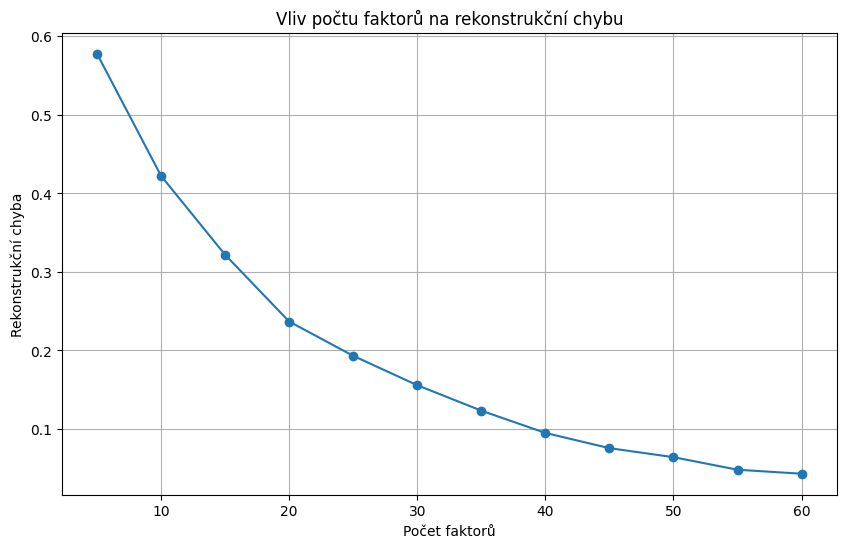

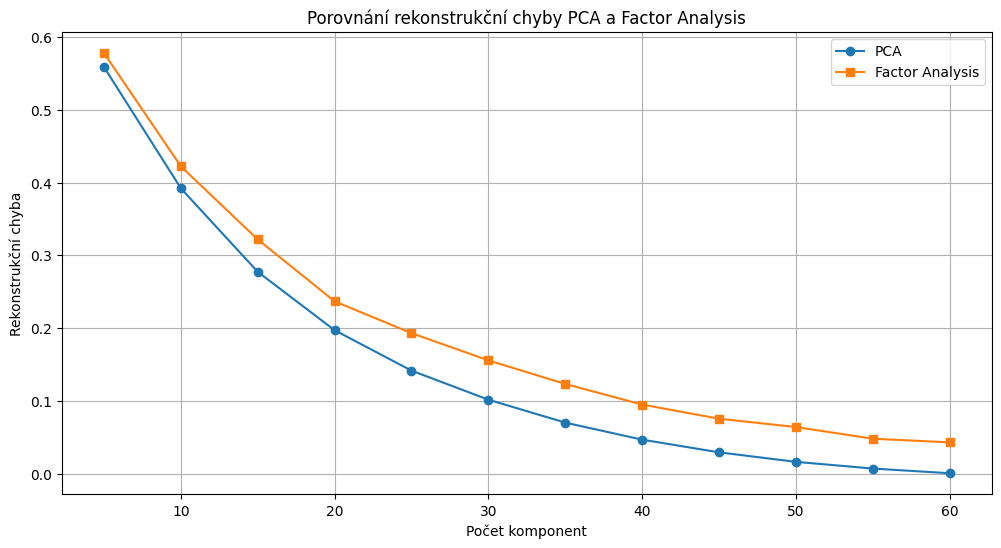

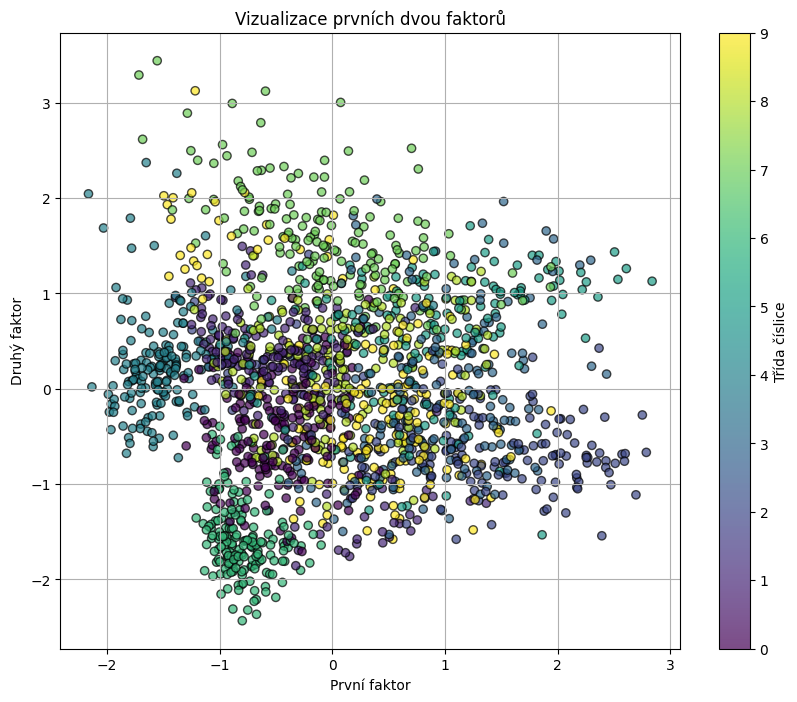

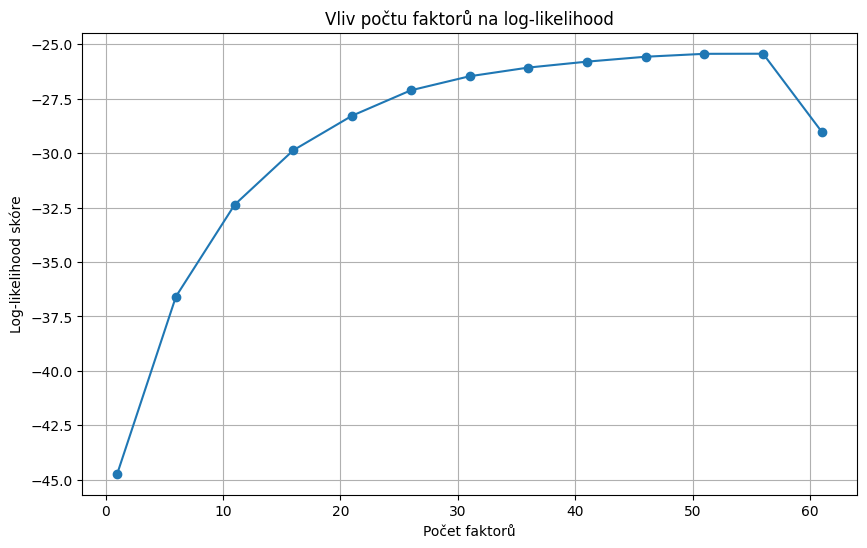

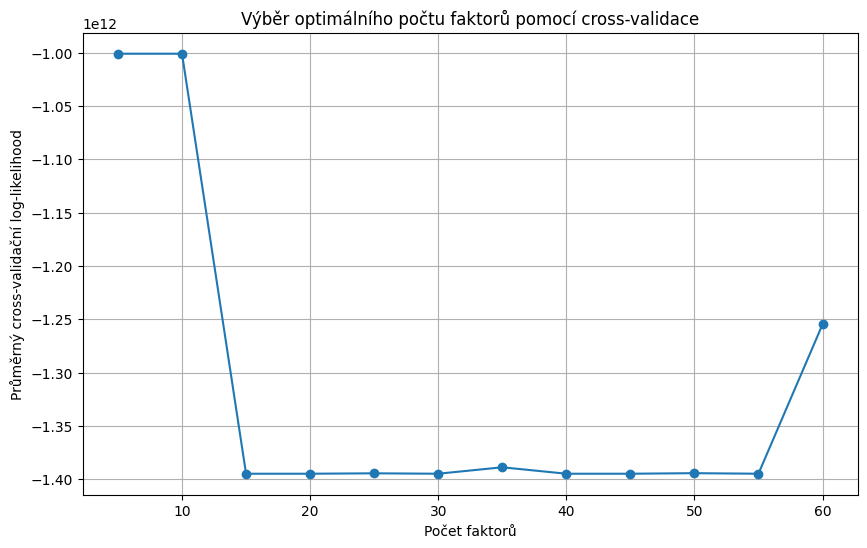

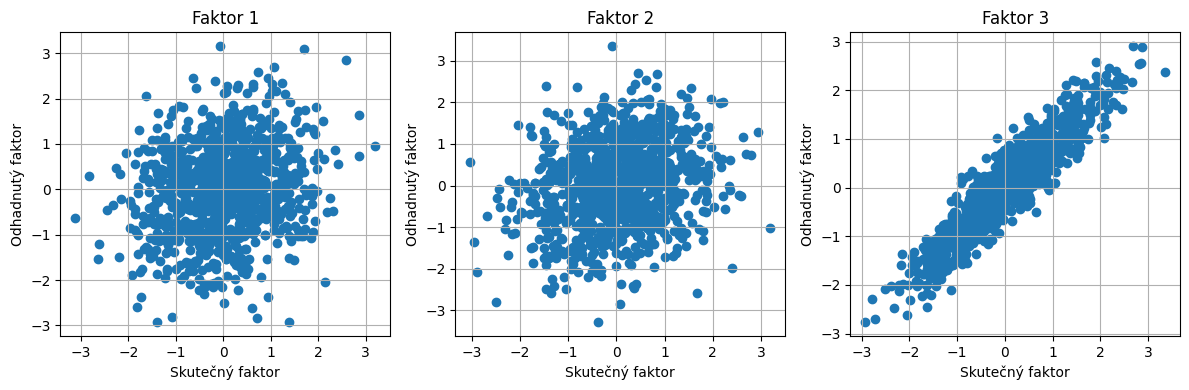

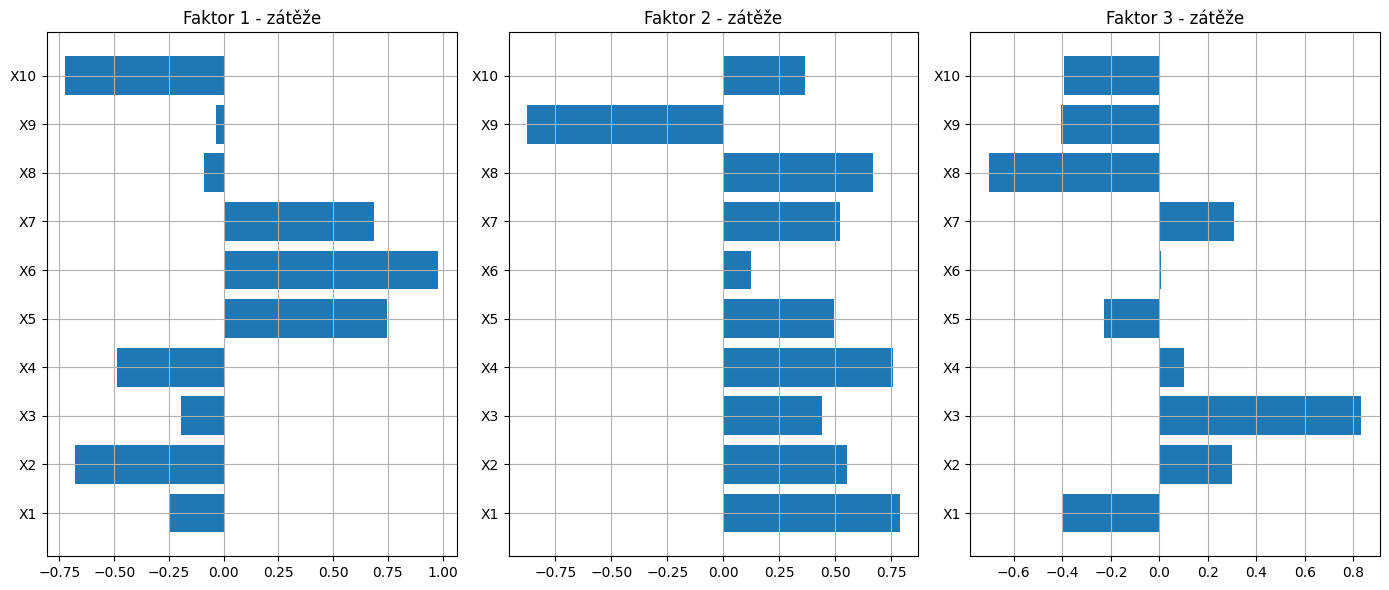

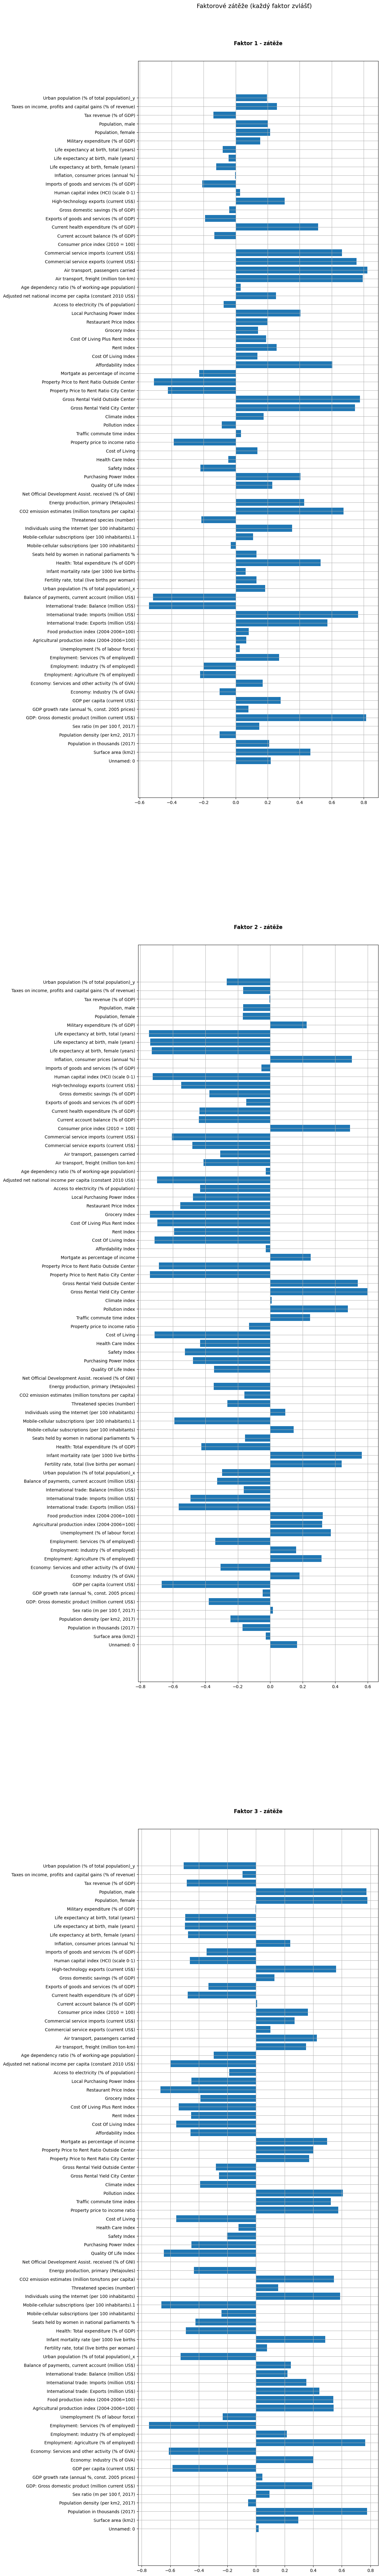

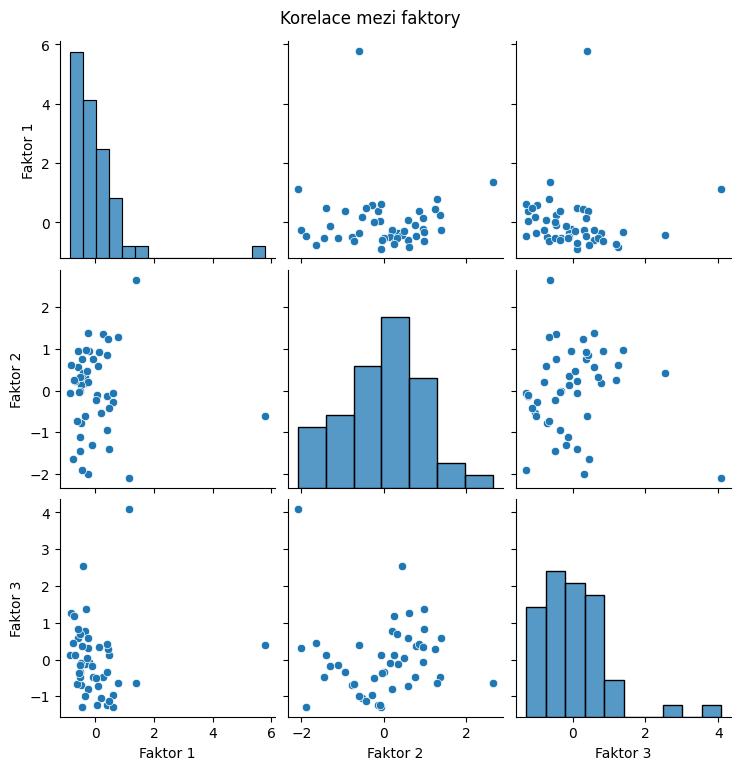

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import FactorAnalysis, PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_digits
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from time import time
import pandas as pd
import seaborn as sns

# Načtení datasetu
digits = load_digits()
X, y = digits.data, digits.target

# Standardizace dat
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplikace Factor Analysis s různým počtem komponent
n_components_range = range(5, 65, 5)
scores = []

for n_comp in n_components_range:
    fa = FactorAnalysis(n_components=n_comp, random_state=42)
    X_fa = fa.fit_transform(X_scaled)
    # Rekonstrukce dat (manuální, protože inverse_transform není k dispozici)
    X_reconstructed = X_fa @ fa.components_ + fa.mean_
    # Výpočet rekonstrukční chyby
    score = np.mean((X_scaled - X_reconstructed) ** 2)
    scores.append(score)

# Vizualizace rekonstrukční chyby
plt.figure(figsize=(10, 6))
plt.plot(n_components_range, scores, 'o-')
plt.xlabel('Počet faktorů')
plt.ylabel('Rekonstrukční chyba')
plt.title('Vliv počtu faktorů na rekonstrukční chybu')
plt.grid(True)
plt.show()

# Porovnání Factor Analysis a PCA
pca_scores = []
fa_scores = []
n_components_range = range(5, 65, 5)

for n_comp in n_components_range:
    # PCA
    pca = PCA(n_components=n_comp)
    X_pca = pca.fit_transform(X_scaled)
    X_reconstructed_pca = pca.inverse_transform(X_pca)
    pca_scores.append(np.mean((X_scaled - X_reconstructed_pca) ** 2))
    
    # Factor Analysis
    fa = FactorAnalysis(n_components=n_comp, random_state=42)
    X_fa = fa.fit_transform(X_scaled)
    X_reconstructed_fa = X_fa @ fa.components_ + fa.mean_
    fa_scores.append(np.mean((X_scaled - X_reconstructed_fa) ** 2))

# Vizualizace porovnání
plt.figure(figsize=(12, 6))
plt.plot(n_components_range, pca_scores, 'o-', label='PCA')
plt.plot(n_components_range, fa_scores, 's-', label='Factor Analysis')
plt.xlabel('Počet komponent')
plt.ylabel('Rekonstrukční chyba')
plt.title('Porovnání rekonstrukční chyby PCA a Factor Analysis')
plt.legend()
plt.grid(True)
plt.show()

# Aplikace Factor Analysis s optimálním počtem komponent
optimal_n_comp = 30  # Na základě grafu rekonstrukční chyby
fa = FactorAnalysis(n_components=optimal_n_comp, random_state=42)
X_fa = fa.fit_transform(X_scaled)

# Vizualizace prvních dvou faktorů
plt.figure(figsize=(10, 8))
plt.scatter(X_fa[:, 0], X_fa[:, 1], c=y, cmap='viridis', edgecolor='k', alpha=0.7)
plt.colorbar(label='Třída číslice')
plt.xlabel('První faktor')
plt.ylabel('Druhý faktor')
plt.title('Vizualizace prvních dvou faktorů')
plt.grid(True)
plt.show()

# Určení optimálního počtu faktorů pomocí LL (log-likelihood)
n_components_range = range(1, 65, 5)
ll_scores = []

for n_comp in n_components_range:
    fa = FactorAnalysis(n_components=n_comp, random_state=42)
    fa.fit(X_scaled)
    ll_scores.append(fa.score(X_scaled))

# Vizualizace log-likelihood
plt.figure(figsize=(10, 6))
plt.plot(n_components_range, ll_scores, 'o-')
plt.xlabel('Počet faktorů')
plt.ylabel('Log-likelihood skóre')
plt.title('Vliv počtu faktorů na log-likelihood')
plt.grid(True)
plt.show()

# Výběr optimálního počtu faktorů pomocí cross-validace
n_components_range = range(5, 65, 5)
cv_scores = []

for n_comp in n_components_range:
    fa = FactorAnalysis(n_components=n_comp, random_state=42)
    scores = cross_val_score(fa, X_scaled, cv=5)
    cv_scores.append(np.mean(scores))

# Vizualizace cross-validačního skóre
plt.figure(figsize=(10, 6))
plt.plot(n_components_range, cv_scores, 'o-')
plt.xlabel('Počet faktorů')
plt.ylabel('Průměrný cross-validační log-likelihood')
plt.title('Výběr optimálního počtu faktorů pomocí cross-validace')
plt.grid(True)
plt.show()

# Ukázka použití Factor Analysis pro syntetická data s korelovanými faktory
n_samples = 1000
n_features = 10
n_factors = 3

W = np.random.randn(n_factors, n_features)
true_factors = np.random.randn(n_samples, n_factors)
noise = 0.5 * np.random.randn(n_samples, n_features)
X_synth = np.dot(true_factors, W) + noise

X_synth_scaled = StandardScaler().fit_transform(X_synth)

fa_synth = FactorAnalysis(n_components=n_factors, random_state=42)
factors_estimated = fa_synth.fit_transform(X_synth_scaled)

plt.figure(figsize=(12, 4))
for i in range(n_factors):
    plt.subplot(1, n_factors, i+1)
    plt.scatter(true_factors[:, i], factors_estimated[:, i])
    plt.title(f'Faktor {i+1}')
    plt.xlabel('Skutečný faktor')
    plt.ylabel('Odhadnutý faktor')
    plt.grid(True)
plt.tight_layout()
plt.show()

components = fa_synth.components_
feature_names = [f"X{i+1}" for i in range(n_features)]

plt.figure(figsize=(14, 6))
for i in range(n_factors):
    plt.subplot(1, n_factors, i+1)
    plt.barh(range(n_features), components[i, :], align='center')
    plt.yticks(range(n_features), feature_names)
    plt.title(f'Faktor {i+1} - zátěže')
    plt.grid(True)
plt.tight_layout()
plt.show()

# # Reálný socioekonomický dataset (volitelný) -------------------------------------------------------------------------
# # Předpokládáme, že df už obsahuje načtený DataFrame s číselnými daty
df_numeric = df.select_dtypes(include=[np.number]).dropna()
feature_names = df_numeric.columns
n_features = len(feature_names)
n_factors = 3

# Standardizace dat
X_eco = df_numeric.values
X_eco_scaled = StandardScaler().fit_transform(X_eco)

# Factor Analysis s 3 komponentami
fa_eco = FactorAnalysis(n_components=n_factors, random_state=42)
X_fa_eco = fa_eco.fit_transform(X_eco_scaled)

# Faktorové zátěže
components = fa_eco.components_

# ✅ Dynamicky vypočítaná výška grafu
height_per_feature = 0.4
total_height = n_factors * n_features * height_per_feature

# Vizualizace faktorových zátěží
fig, axes = plt.subplots(n_factors, 1, figsize=(10, total_height), sharex=False)

if n_factors == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    ax.barh(range(n_features), components[i, :], align='center')
    ax.set_yticks(range(n_features))
    ax.set_yticklabels(feature_names)
    ax.grid(True)
    
    # ✅ Místo set_title použijeme ax.text pro menší vertikální prostor
    ax.text(0.5, 1.02, f'Faktor {i + 1} - zátěže', transform=ax.transAxes,
            ha='center', va='bottom', fontsize=12, fontweight='bold')

# ✅ Nadpis celé sekce s minimálním odsazením
fig.suptitle("Faktorové zátěže (každý faktor zvlášť)", fontsize=14, y=0.995)
fig.subplots_adjust(top=0.975, hspace=0.2)

plt.show()

# Korelace mezi faktory
factor_df = pd.DataFrame(X_fa_eco, columns=[f'Faktor {i+1}' for i in range(n_factors)])
sns.pairplot(factor_df)
plt.suptitle('Korelace mezi faktory', y=1.02)
plt.show()

# # Reálný socioekonomický dataset (volitelný) -------------------------------------------------------------------------
# # Předpokládáme, že df už obsahuje načtený DataFrame s číselnými daty
# df_numeric = df.select_dtypes(include=[np.number]).dropna()
# feature_names = df_numeric.columns
# n_features = len(feature_names)
# n_factors = 3

# # Standardizace dat
# X_eco = df_numeric.values
# X_eco_scaled = StandardScaler().fit_transform(X_eco)

# # Factor Analysis s 3 komponentami
# fa_eco = FactorAnalysis(n_components=n_factors, random_state=42)
# X_fa_eco = fa_eco.fit_transform(X_eco_scaled)

# # Faktorové zátěže
# components = fa_eco.components_

# # ✅ Dynamicky upravená výška grafu: 0.4 palce na jednu proměnnou na jeden faktor
# height_per_feature = 0.4
# total_height = n_factors * n_features * height_per_feature

# # Vizualizace faktorových zátěží (vertikální layout)
# fig, axes = plt.subplots(n_factors, 1, figsize=(10, total_height))

# if n_factors == 1:
#     axes = [axes]

# for i, ax in enumerate(axes):
#     ax.barh(range(n_features), components[i, :], align='center')
#     ax.set_yticks(range(n_features))
#     ax.set_yticklabels(feature_names)
#     ax.set_title(f'Faktor {i + 1} - zátěže')
#     ax.grid(True)

# plt.tight_layout()
# plt.suptitle("Faktorové zátěže (každý faktor zvlášť)", fontsize=14, y=1.01)
# plt.subplots_adjust(hspace=0.5)
# plt.show()

# # ✅ Vizualizace korelace mezi faktory (seaborn pairplot)
# factor_df = pd.DataFrame(X_fa_eco, columns=[f'Faktor {i+1}' for i in range(n_factors)])
# sns.pairplot(factor_df)
# plt.suptitle('Korelace mezi faktory', y=1.02)
# plt.show()

## Reálný socioekonomický dataset (volitelný) --------------------------------------------------------------------------
# # Předpokládáme, že df už obsahuje načtený DataFrame s číselnými daty
# df_numeric = df.select_dtypes(include=[np.number]).dropna()
# feature_names = df_numeric.columns

# # Standardizace dat
# X_eco = df_numeric.values
# X_eco_scaled = StandardScaler().fit_transform(X_eco)

# # Factor Analysis s 3 komponentami
# fa_eco = FactorAnalysis(n_components=3, random_state=42)
# X_fa_eco = fa_eco.fit_transform(X_eco_scaled)

# # Faktorové zátěže
# components = fa_eco.components_

# # Vizualizace faktorových zátěží
# plt.figure(figsize=(14, 8))
# for i in range(3):
#     plt.subplot(1, 3, i + 1)
#     plt.barh(range(len(feature_names)), components[i, :], align='center')
#     plt.yticks(range(len(feature_names)), feature_names)
#     plt.title(f'Faktor {i + 1} - zátěže')
#     plt.grid(True)
# plt.tight_layout()
# plt.show()

# # Vizualizace korelace mezi faktory
# factor_df = pd.DataFrame(X_fa_eco, columns=[f'Faktor {i+1}' for i in range(3)])
# sns.pairplot(factor_df)
# plt.suptitle('Korelace mezi faktory', y=1.02)
# plt.show()

# # Reálný socioekonomický dataset (volitelný) -------------------------------------------------------------------------
# try:
#     # 404: Not Found
#     # df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/socio_economic.csv')
#     df = df.select_dtypes(include=[np.number]).dropna()
#     feature_names = df.columns
    
#     X_eco = df.values
#     X_eco_scaled = StandardScaler().fit_transform(X_eco)
    
#     fa_eco = FactorAnalysis(n_components=3, random_state=42)
#     X_fa_eco = fa_eco.fit_transform(X_eco_scaled)
    
#     components = fa_eco.components_
    
#     plt.figure(figsize=(14, 8))
#     for i in range(3):
#         plt.subplot(1, 3, i+1)
#         plt.barh(range(len(feature_names)), components[i, :], align='center')
#         plt.yticks(range(len(feature_names)), feature_names)
#         plt.title(f'Faktor {i+1} - zátěže')
#         plt.grid(True)
#     plt.tight_layout()
#     plt.show()
    
#     plt.figure(figsize=(10, 8))
#     factor_df = pd.DataFrame(X_fa_eco, columns=[f'Faktor {i+1}' for i in range(3)])
#     sns.pairplot(factor_df)
#     plt.suptitle('Korelace mezi faktory')
#     plt.show()
# except:
#     print("Ukázka s reálnými daty přeskočena.")

## Srovnávací tabulka metod redukce dimenzionality

| Metoda | Typ | Výpočetní náročnost | Zachování lokální struktury | Zachování globální struktury | Interpretovatelnost | Použití pro nová data | Hlavní výhody | Hlavní nevýhody |
|--------|-----|---------------------|---------------------------|-------------------------------|---------------------|---------------------|--------------|----------------|
| PCA | Lineární | Nízká | Nízká | Vysoká | Střední | Ano | Rychlost, jednoduchost, zachování globální variance | Pouze lineární transformace, nezachovává lokální strukturu |
| t-SNE | Nelineární | Vysoká | Vysoká | Nízká | Nízká | Ne | Excelentní vizualizace shluků, zachování lokální struktury | Výpočetně náročná, nevhodná pro velká data, nelze použít pro nová data |
| TruncatedSVD | Lineární | Nízká | Nízká | Vysoká | Střední | Ano | Efektivní pro řídké matice, využití v NLP | Podobné limitace jako PCA, pouze lineární transformace |
| UMAP | Nelineární | Střední | Vysoká | Střední | Nízká | Ano | Rychlejší než t-SNE, zachovává globální i lokální strukturu, použitelná pro nová data | Externí závislost, citlivá na hyperparametry, složitější implementace |
| FactorAnalysis | Lineární | Střední | Nízká | Střední | Vysoká | Ano | Odděluje šum od společné variance, generativní model | Složitější interpretace, více předpokladů o datech, citlivá na velikost vzorku |